# **Members Info:**
## 1. Faika Fairuz (Id: E241412)
## 2. Kazi Jannatul Mawa (Id: E241426)
## 3. Arjun Nahar Arin (Id: E241447)
##**Dataset:** **https://www.kaggle.com/datasets/shahnawaj9/diabetes-database**

# Library and Data Set

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Datasets/diabetes.csv")

print("1. Dataset Shape:", df.shape)
print("\n2. First 5 rows:\n")
print(df.head())
print("\n3. Dataset Info:\n")
df.info()
print("\n4. Summary Statistics:\n:")
print(df.describe())
print("\n5. Missing Values:\n")
display(df.isnull().sum())
print("\n6. Duplicate Rows: ")
print(df.duplicated().sum())
print("\n7. Unique Values:\n")
display(df.nunique())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. Dataset Shape: (768, 9)

2. First 5 rows:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

3. Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



6. Duplicate Rows: 
0

7. Unique Values:



,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


### Counting Zero Values (Potentially Missing Data)

In [ ]:
columns_with_zeros_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zeros_as_missing:
    zero_count = (df[col] == 0).sum()
    print(f"Number of zero values in '{col}': {zero_count}")


Number of zero values in 'Glucose': 5
Number of zero values in 'BloodPressure': 35
Number of zero values in 'SkinThickness': 227
Number of zero values in 'Insulin': 374
Number of zero values in 'BMI': 11


# Droping Insuline & SkinThickness Column

In [ ]:
df = df.drop(['SkinThickness', 'Insulin'], axis=1)
df.head(768). style. background_gradient (cmap="YlOrRd")

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.600000,0.627000,50,1
1,1,85,66,26.600000,0.351000,31,0
2,8,183,64,23.300000,0.672000,32,1
3,1,89,66,28.100000,0.167000,21,0
4,0,137,40,43.100000,2.288000,33,1
5,5,116,74,25.600000,0.201000,30,0
6,3,78,50,31.000000,0.248000,26,1
7,10,115,0,35.300000,0.134000,29,0
8,2,197,70,30.500000,0.158000,53,1
9,8,125,96,0.000000,0.232000,54,1


# Handle zero values and replace them with the mean

In [ ]:
zero_cols_extended = ['Glucose', 'BloodPressure', 'BMI' ]
for col in zero_cols_extended:
    df[col] = df[col].replace(0, df[col].mean())

print("Mean values used for replacement (extended columns):")
print(df[zero_cols_extended].mean())

# Display the first few rows of the DataFrame to show the changes
print("\nDataFrame head after replacement:")
display(df.head())

Mean values used for replacement (extended columns):
Glucose          121.681605
BloodPressure     72.254807
BMI               32.450805
dtype: float64

DataFrame head after replacement:


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,33.6,0.627,50,1
1,1,85.0,66.0,26.6,0.351,31,0
2,8,183.0,64.0,23.3,0.672,32,1
3,1,89.0,66.0,28.1,0.167,21,0
4,0,137.0,40.0,43.1,2.288,33,1


# Check data Balancing

In [ ]:
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


/tmp/ipykernel_5208/1208175529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette=['skyblue', 'lightcoral'])


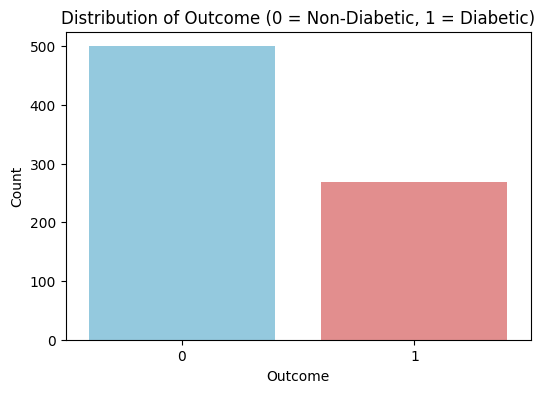

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x='Outcome', data=df, palette=['skyblue', 'lightcoral'])
plt.title('Distribution of Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

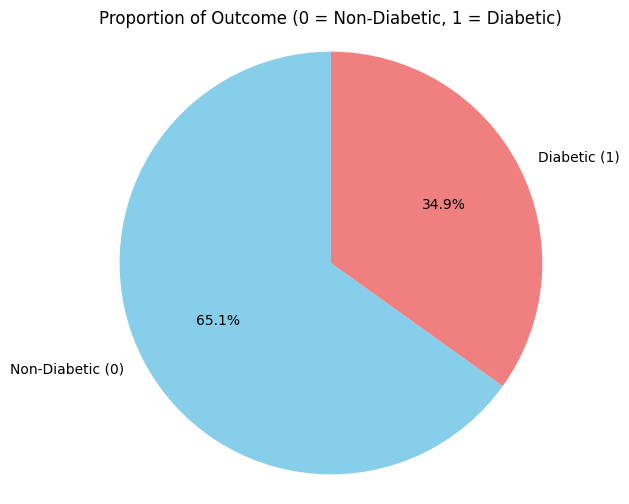

In [ ]:
outcome_counts = df['Outcome'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(outcome_counts, labels=['Non-Diabetic (0)', 'Diabetic (1)'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Proportion of Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Apply SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) based on previous steps in the notebook
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data into training and testing sets
# Assuming `x_filtered` and `y_filtered` referred to X and y, as `x_filtered` is not defined elsewhere.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())

Outcome
0    400
1    400
Name: count, dtype: int64


In [ ]:
X_train_smote.shape, y_train_smote.shape

((800, 6), (800,))

In [ ]:
y_train_smote.value_counts(normalize = True )

,proportion
Outcome,
0,0.5
1,0.5


/tmp/ipykernel_5208/3492972818.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette='coolwarm')


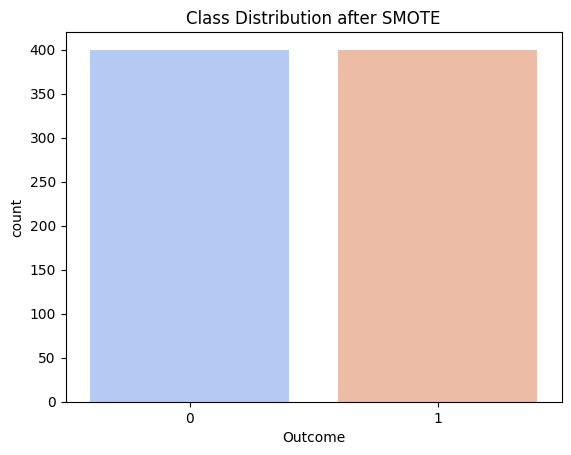

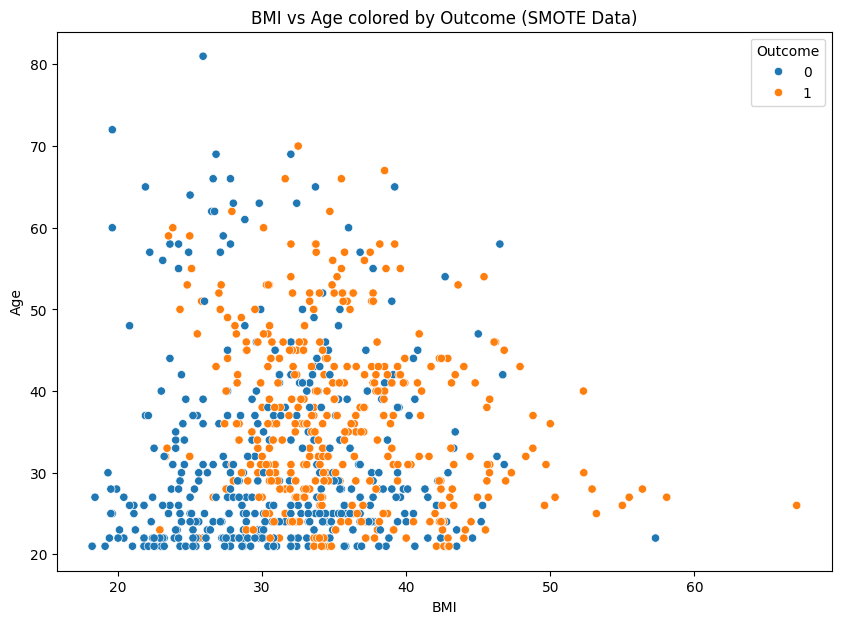

In [ ]:
sns.countplot(x=y_train_smote, palette='coolwarm')
plt.title('Class Distribution after SMOTE')
plt.show()

df_os = pd.concat([X_train_smote, y_train_smote], axis=1)

plt.figure(figsize=(10,7))
sns.scatterplot(data = df_os,x='BMI',y='Age',hue = 'Outcome')
plt.title('BMI vs Age colored by Outcome (SMOTE Data)')
plt.show()

# Univariate Analysis:

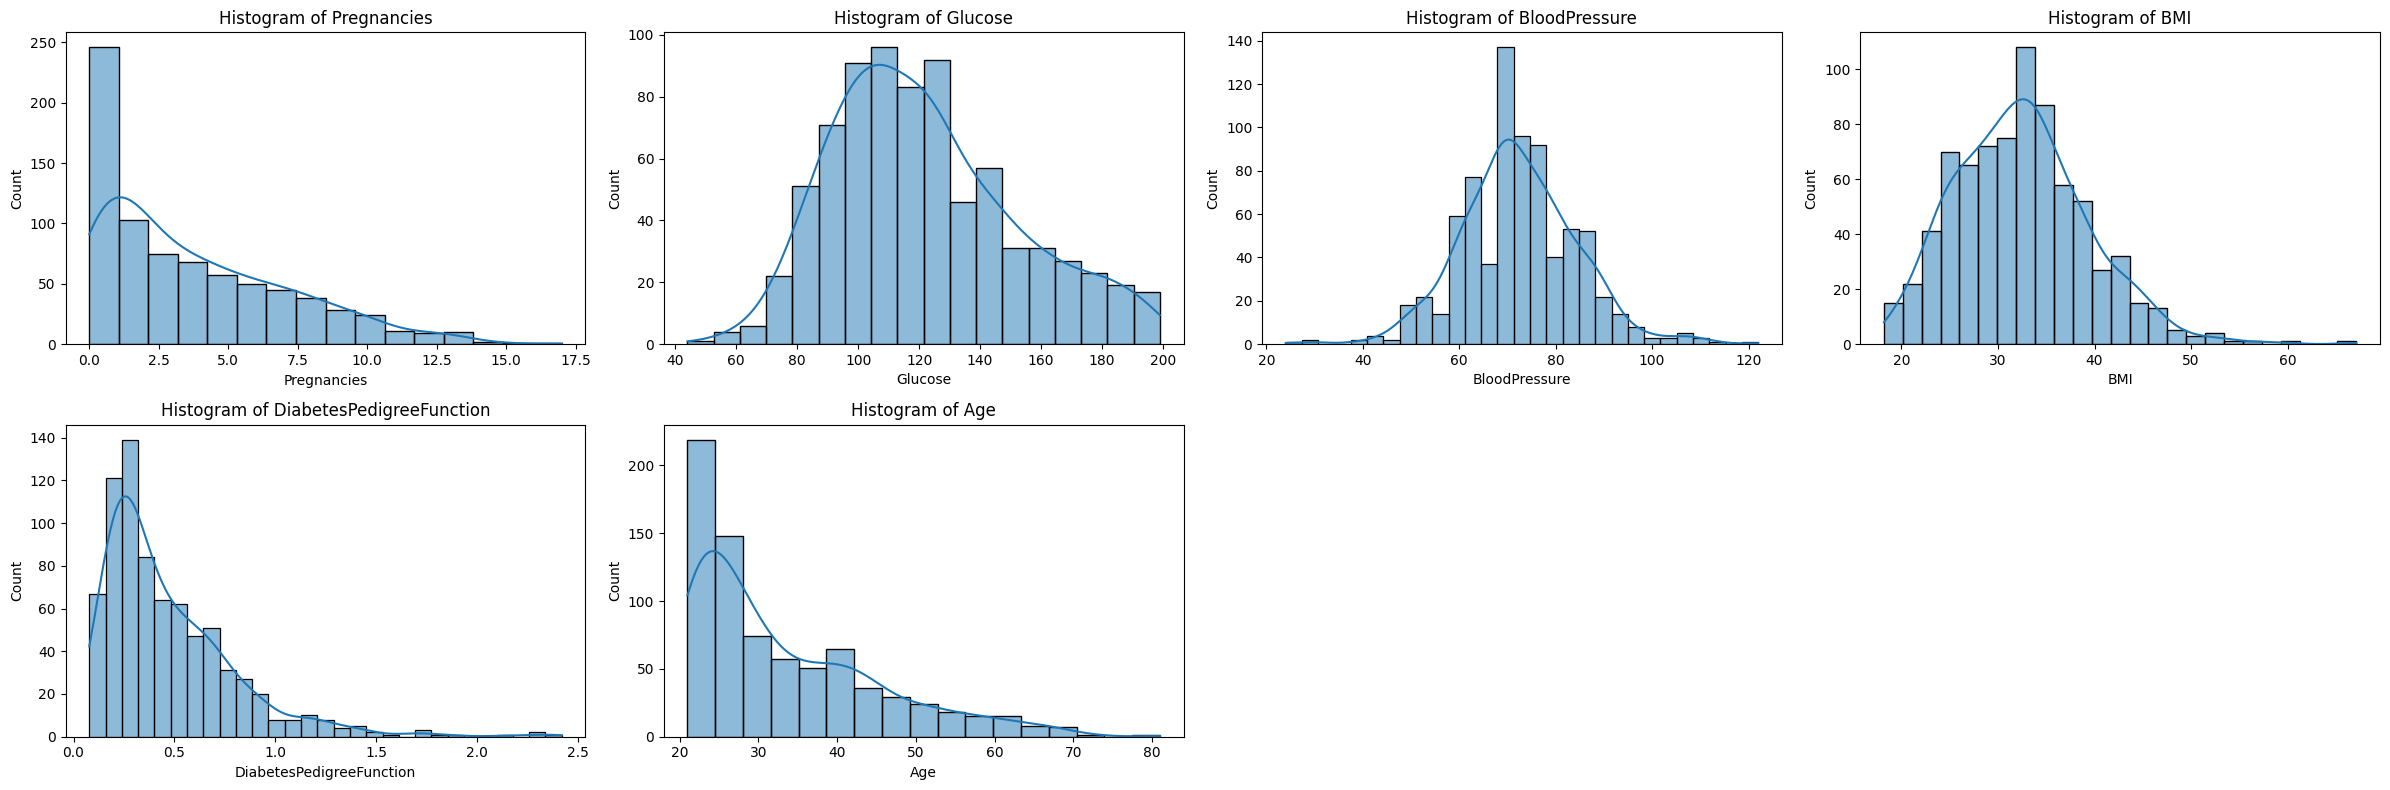

In [ ]:
numerical_cols = [ 'Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Calculate the number of rows and columns for the subplots
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplots

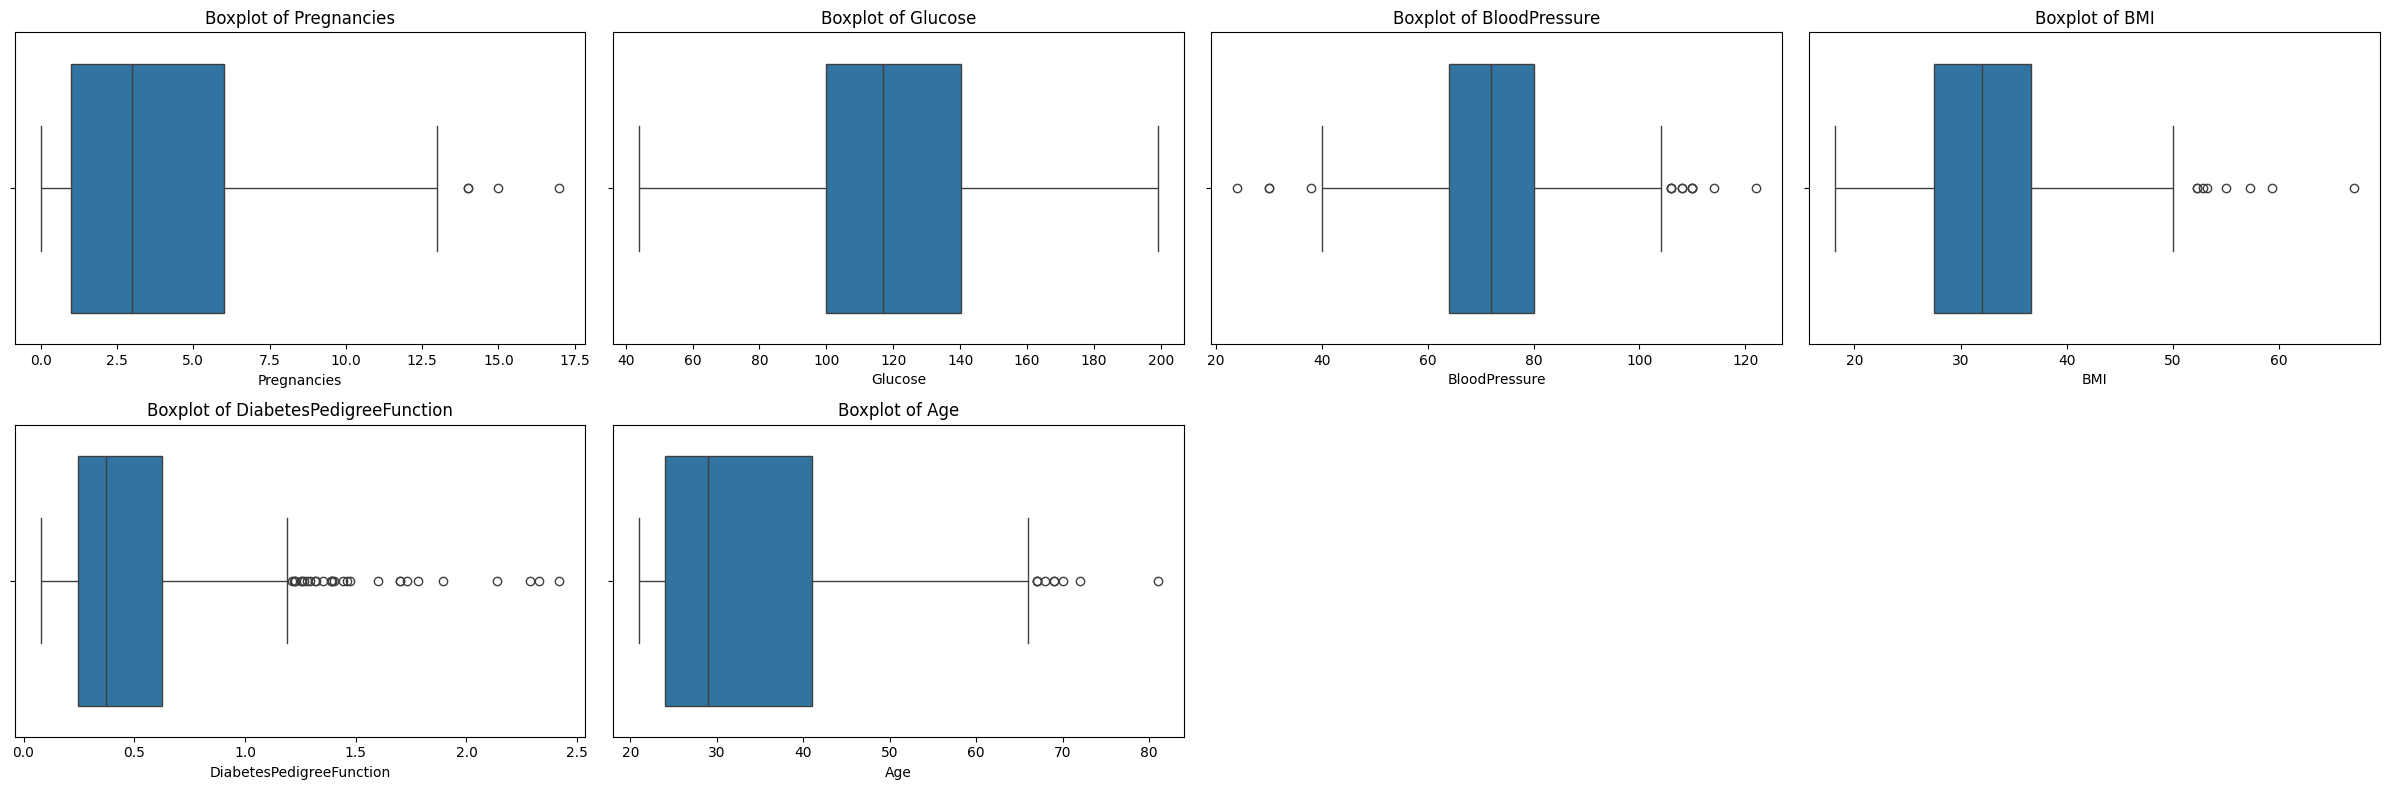

In [ ]:
numerical_cols = ['Pregnancies','Glucose', 'BloodPressure','BMI', 'DiabetesPedigreeFunction', 'Age']
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Ceiling division for rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### KDE Plots

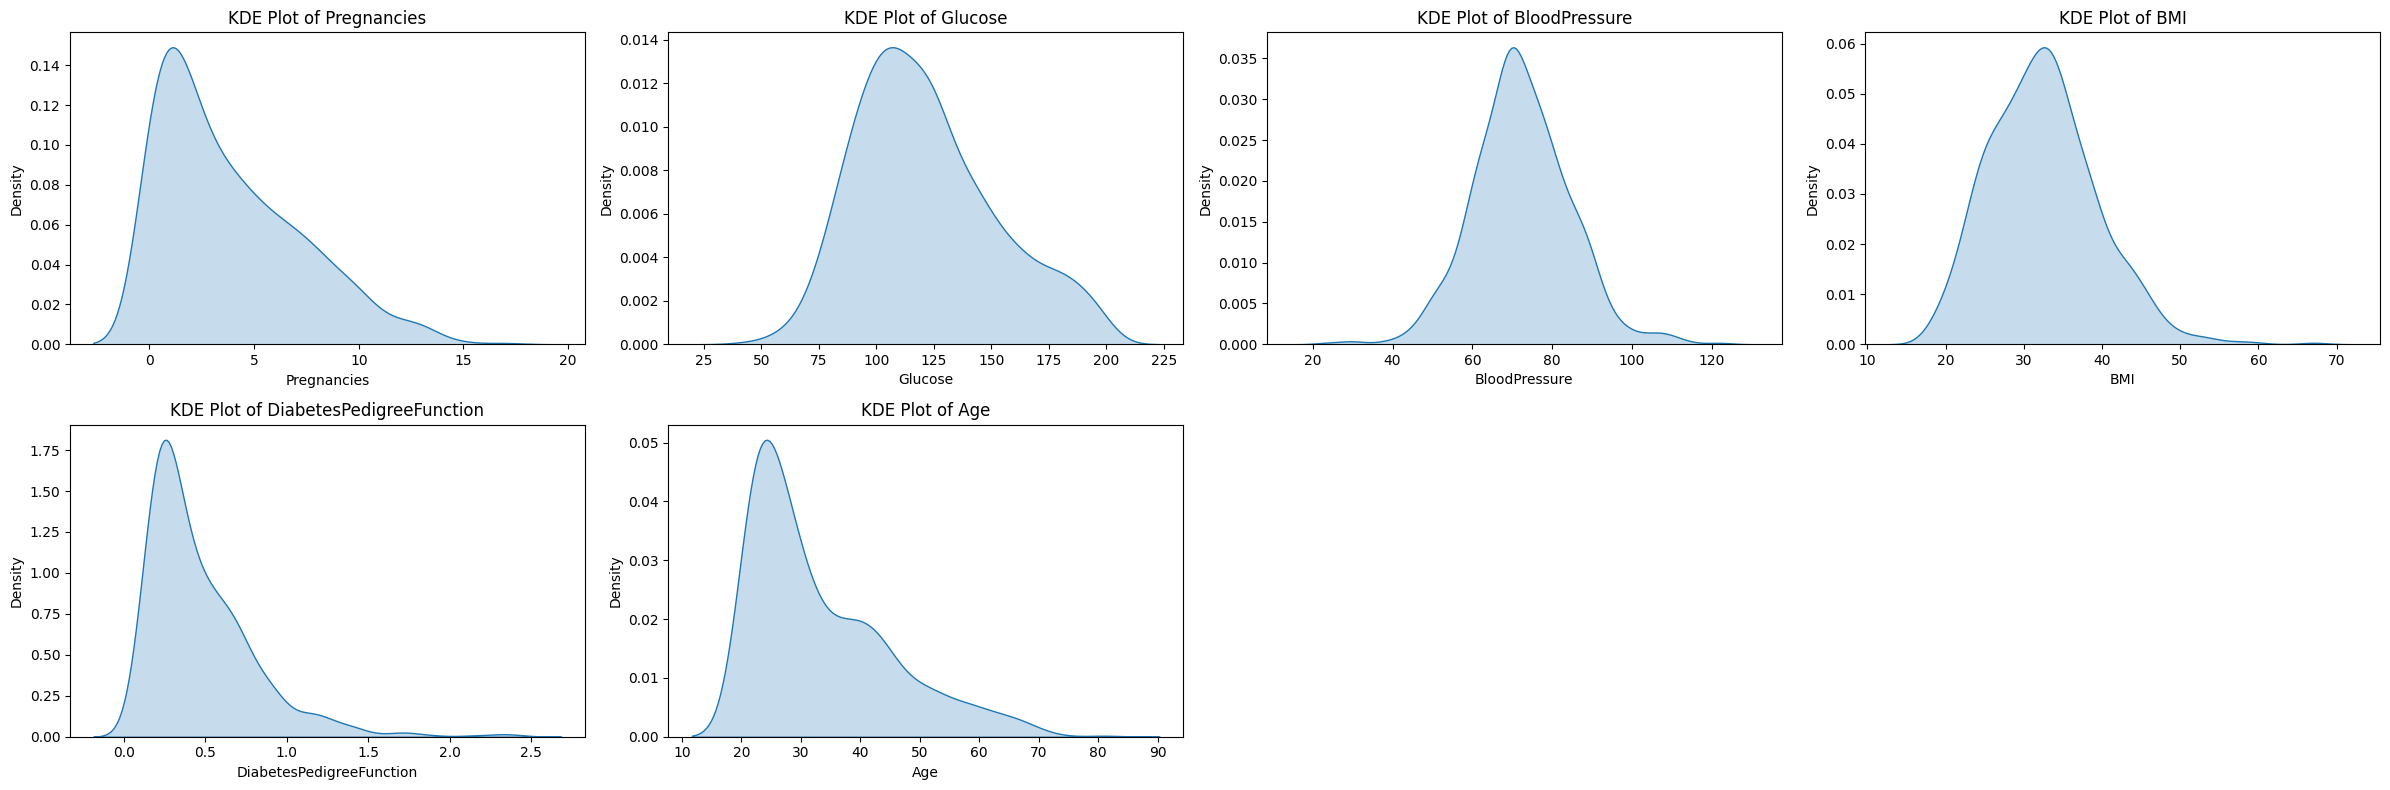

In [ ]:
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Calculate the number of rows and columns for the subplots
n_cols = 4 # Aim for 4 columns per row for better spacing
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, col in enumerate(numerical_cols):
    sns.kdeplot(x=df[col], fill=True, ax=axes[i])
    axes[i].set_title(f'KDE Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Bivariate Analysis:

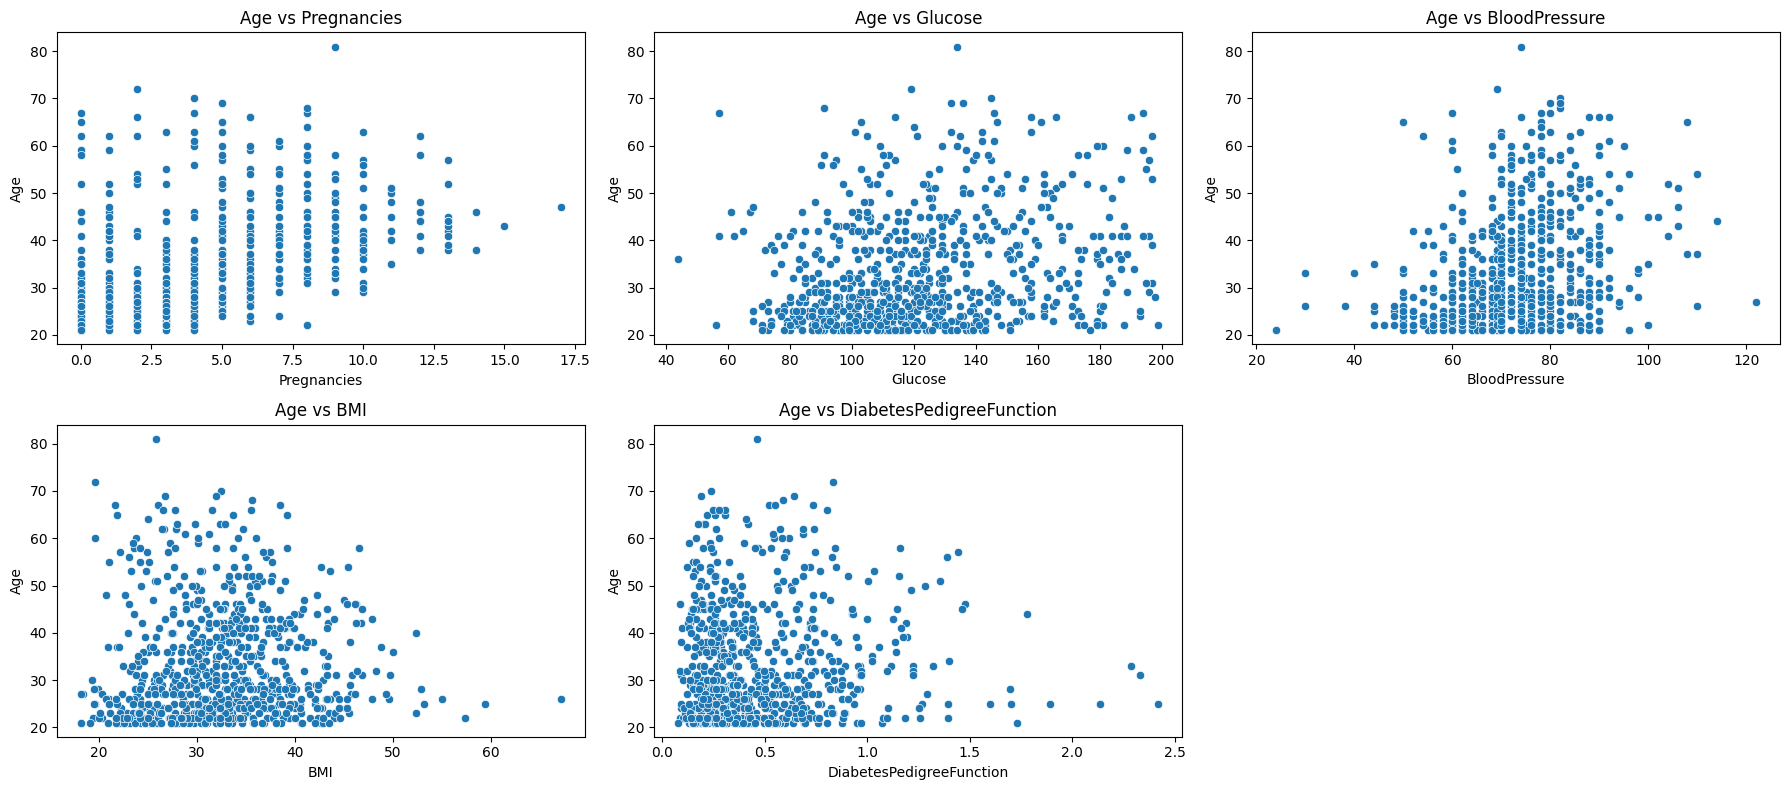

In [ ]:
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']

# Calculate the number of rows and columns for the subplots
n_cols = 3 # To get 2 rows for 6 plots (6 / 2 = 3)
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

for i, col in enumerate(numerical_cols):
    sns.scatterplot(x=df[col], y=df['Age'], ax=axes[i])
    axes[i].set_title(f'Age vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Age')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Multivariate Analysis:

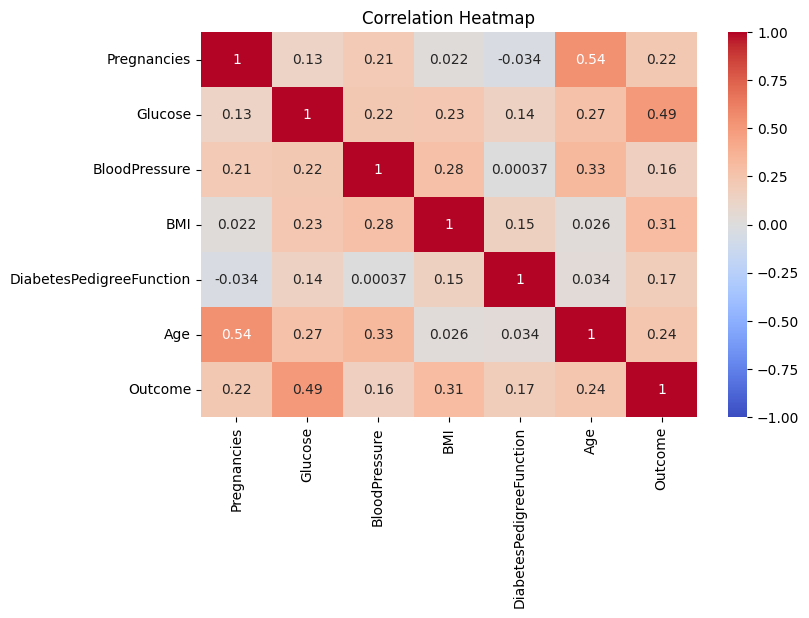

In [ ]:
numerical_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']
plt.figure(figsize=(8, 5))
Correlation_matrix = df.corr()
sns.heatmap(Correlation_matrix, annot=True, cmap='coolwarm',vmin=-1,vmax=1)
plt.title(f'Correlation Heatmap')
plt.show()

# Define features (X) and target (y)

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print(X.shape,y.shape)
X.info()

(768, 6) (768,)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 36.1 KB


# Outlier Checking

In [ ]:
print("Percentage of Outliers for Each Feature (using IQR method):\n")
outlier_percentages = {}
for column in X.columns:
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = X[(X[column] < lower_bound) | (X[column] > upper_bound)]
    outlier_count = len(outliers)

    # Calculate percentage
    total_count = len(X)
    percentage = (outlier_count / total_count) * 100
    outlier_percentages[column] = percentage
    print(f"{column}: {percentage:.2f}%")

Percentage of Outliers for Each Feature (using IQR method):

Pregnancies: 0.52%
Glucose: 0.00%
BloodPressure: 1.82%
BMI: 1.04%
DiabetesPedigreeFunction: 3.78%
Age: 1.17%


# Split the data into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

# Use the filtered data (x_filtered, y_filtered) from the Isolation Forest step
# NOTE: x_filtered and y_filtered were not defined. Using X and y from the main DataFrame.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nOriginal class distribution in y_train:\n{y_train.value_counts()}")

X_train shape: (614, 6)
X_test shape: (154, 6)
y_train shape: (614,)
y_test shape: (154,)

Original class distribution in y_train:
Outcome
0    400
1    214
Name: count, dtype: int64


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd # Import pandas to use DataFrame for display

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_smote)
X_test_scaled = sc.transform(X_test)

# Convert to DataFrame for displaying the head
print("Scaled Training Features: ")
display(pd.DataFrame(X_train_scaled, columns=X_train_smote.columns).head())
print("Scaled Testing Features: ")
display(pd.DataFrame(X_test_scaled, columns=X_test.columns).head())

Scaled Training Features: 


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,-0.867485,-1.179009,-0.893429,-0.898969,0.263898,-0.861189
1,0.341553,-0.000598,0.449989,-0.540753,-0.167632,0.548250
2,-0.565226,-0.688004,-1.229283,0.250308,-0.822578,-0.773099
3,-0.867485,0.654074,-1.397210,-0.525827,0.214930,-0.420740
4,-1.169745,-1.015341,-0.725501,1.698098,-0.391048,-1.037369


Scaled Testing Features: 


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,0.946073,1.079612,-0.725501,-0.869118,-0.611403,0.548250
1,1.852852,-1.899149,2.800970,0.339862,-0.638948,1.164879
2,-0.565226,-0.131533,0.282062,0.399565,-0.032970,-0.685009
3,0.946073,-0.393402,-0.725501,-0.869118,0.729093,0.019710
4,-0.565226,-1.702747,-0.296828,-0.183644,-1.199018,-1.037369


# Evaluate Baseline Models

Logistic Regression Accuracy: 0.7208

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       100
           1       0.59      0.69      0.63        54

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



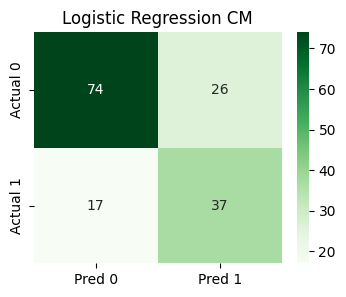

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# --- Logistic Regression Baseline ---
lr_model = LogisticRegression(random_state=42, solver='liblinear')
lr_model.fit(X_train_scaled, y_train_smote)

y_pred_lr = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"\nClassification Report for Logistic Regression:\n{classification_report(y_test, y_pred_lr)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Logistic Regression CM")
plt.show()

KNN Accuracy: 0.6883

Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       100
           1       0.54      0.69      0.61        54

    accuracy                           0.69       154
   macro avg       0.67      0.69      0.67       154
weighted avg       0.71      0.69      0.69       154



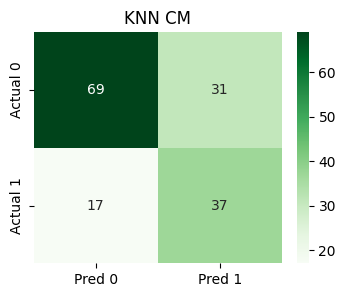

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# --- K-Nearest Neighbors (KNN) Baseline ---
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train_smote)

y_pred_knn = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy: {knn_acc:.4f}")
print(f"\nClassification Report for KNN:\n{classification_report(y_test, y_pred_knn)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("KNN CM")
plt.show()

Gradient Boosting Accuracy: 0.7922

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       100
           1       0.67      0.81      0.73        54

    accuracy                           0.79       154
   macro avg       0.78      0.80      0.78       154
weighted avg       0.81      0.79      0.80       154



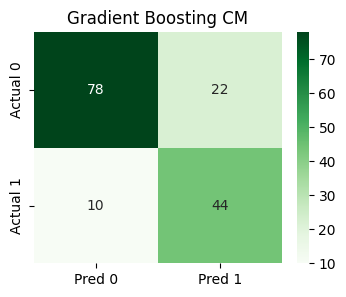

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# --- Gradient Boosting Classifier Baseline ---
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train_scaled, y_train_smote)

y_pred_gbc = gbc_model.predict(X_test_scaled)
gbc_acc = accuracy_score(y_test, y_pred_gbc)

print(f"Gradient Boosting Accuracy: {gbc_acc:.4f}")
print(f"\nClassification Report for Gradient Boosting:\n{classification_report(y_test, y_pred_gbc)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_gbc), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Gradient Boosting CM")
plt.show()

SVM Accuracy: 0.7338

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



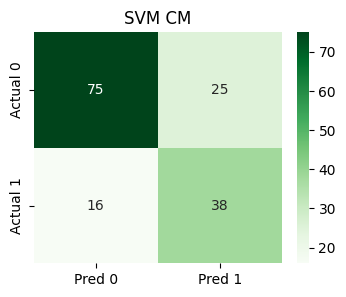

In [ ]:
from sklearn.svm import SVC

# --- Support Vector Machine (SVM) Baseline ---
svm_model = SVC(kernel='linear', random_state=42, probability=True) # probability=True for ROC/PR curves later
svm_model.fit(X_train_scaled, y_train_smote)

y_pred_svm = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {svm_acc:.4f}")
print(f"\nClassification Report for SVM:\n{classification_report(y_test, y_pred_svm)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("SVM CM")
plt.show()

Naive Bayes Accuracy: 0.6883

Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       100
           1       0.54      0.69      0.61        54

    accuracy                           0.69       154
   macro avg       0.67      0.69      0.67       154
weighted avg       0.71      0.69      0.69       154



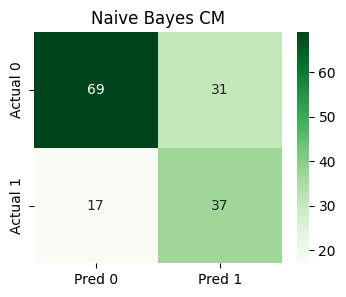

In [ ]:
from sklearn.naive_bayes import GaussianNB

# --- Naive Bayes (Gaussian) Baseline ---
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train_smote)

y_pred_nb = nb_model.predict(X_test_scaled)
nb_acc = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {nb_acc:.4f}")
print(f"\nClassification Report for Naive Bayes:\n{classification_report(y_test, y_pred_nb)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Naive Bayes CM")
plt.show()

Random Forest Accuracy: 0.7597

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       100
           1       0.64      0.70      0.67        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



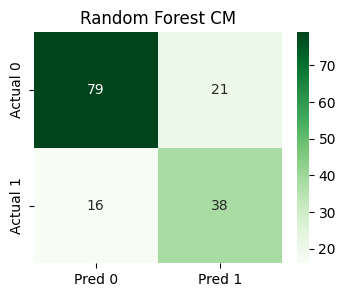

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- Random Forest Classifier Baseline ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_smote)

y_pred_rf = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"\nClassification Report for Random Forest:\n{classification_report(y_test, y_pred_rf)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Random Forest CM")
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:47:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7662

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.65      0.66        54

    accuracy                           0.77       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



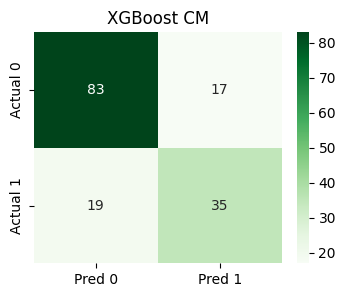

In [ ]:
import xgboost as xgb

# --- XGBoost Classifier Baseline ---
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train_scaled, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print(f"\nClassification Report for XGBoost:\n{classification_report(y_test, y_pred_xgb)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("XGBoost CM")
plt.show()

Decision Tree Accuracy: 0.6883

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.75      0.78      0.76       100
           1       0.56      0.52      0.54        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.68      0.69      0.69       154



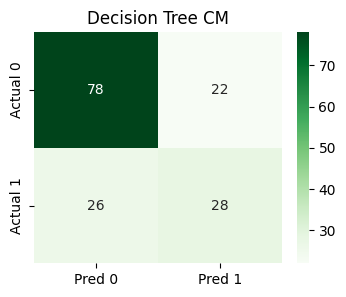

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# --- Decision Tree Classifier Baseline ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train_smote)

y_pred_dt = dt_model.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"\nClassification Report for Decision Tree:\n{classification_report(y_test, y_pred_dt)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Decision Tree CM")
plt.show()

[LightGBM] [Info] Number of positive: 400, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


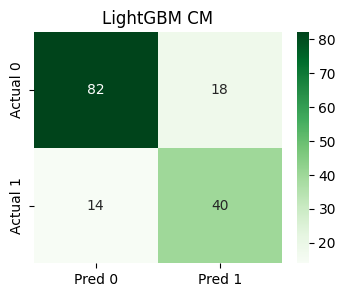

In [ ]:
from lightgbm import LGBMClassifier

# --- LightGBM Classifier Baseline ---
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_scaled, y_train_smote)

y_pred_lgbm = lgbm_model.predict(X_test_scaled)
lgbm_acc = accuracy_score(y_test, y_pred_lgbm)

print(f"LightGBM Accuracy: {lgbm_acc:.4f}")
print(f"\nClassification Report for LightGBM:\n{classification_report(y_test, y_pred_lgbm)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("LightGBM CM")
plt.show()

In [ ]:
import pandas as pd

model_accuracies = {
    'Logistic Regression': lr_acc,
    'K-Nearest Neighbors': knn_acc,
    'Gradient Boosting': gbc_acc,
    'SVM': svm_acc,
    'Naive Bayes': nb_acc,
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'Decision Tree': dt_acc,
    'LightGBM': lgbm_acc
}

accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("Baseline Model Accuracies:")
display(accuracy_df)

best_overall_model_name = accuracy_df.loc[0, 'Model']
best_overall_accuracy = accuracy_df.loc[0, 'Accuracy']

print(f"\nThe overall best performing baseline model is {best_overall_model_name} with an accuracy of {best_overall_accuracy:.4f}.")

Baseline Model Accuracies:


,Model,Accuracy
0,Gradient Boosting,0.792208
1,LightGBM,0.792208
2,XGBoost,0.766234
3,Random Forest,0.759740
4,SVM,0.733766
5,Logistic Regression,0.720779
6,K-Nearest Neighbors,0.688312
7,Naive Bayes,0.688312
8,Decision Tree,0.688312



The overall best performing baseline model is Gradient Boosting with an accuracy of 0.7922.


# Hyperparameter Tuning for Each Model


--- Tuning Logistic Regression ---
Best Parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}
Tuned Logistic Regression Test Accuracy: 0.7208


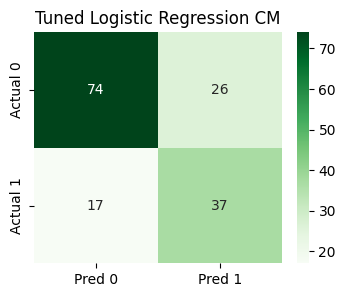

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Logistic Regression Tuning ---
print("\n--- Tuning Logistic Regression ---")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid_search_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train_scaled, y_train_smote)
best_lr_model = grid_search_lr.best_estimator_

y_pred_lr_tuned = best_lr_model.predict(X_test_scaled)
lr_acc_tuned = accuracy_score(y_test, y_pred_lr_tuned)

print(f"Best Parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Tuned Logistic Regression Test Accuracy: {lr_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_lr_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned Logistic Regression CM")
plt.show()


--- Tuning K-Nearest Neighbors ---
Best Parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Tuned KNN Test Accuracy: 0.7078


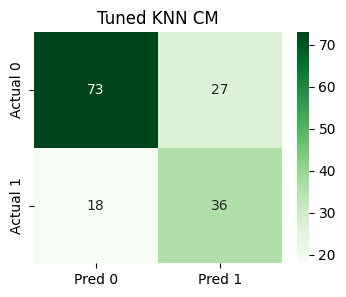

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# --- K-Nearest Neighbors Tuning ---
print("\n--- Tuning K-Nearest Neighbors ---")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_knn.fit(X_train_scaled, y_train_smote)
best_knn_model = grid_search_knn.best_estimator_

y_pred_knn_tuned = best_knn_model.predict(X_test_scaled)
knn_acc_tuned = accuracy_score(y_test, y_pred_knn_tuned)

print(f"Best Parameters for KNN: {grid_search_knn.best_params_}")
print(f"Tuned KNN Test Accuracy: {knn_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_knn_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned KNN CM")
plt.show()


--- Tuning Gradient Boosting Classifier ---
Best Parameters for Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Tuned Gradient Boosting Test Accuracy: 0.7662


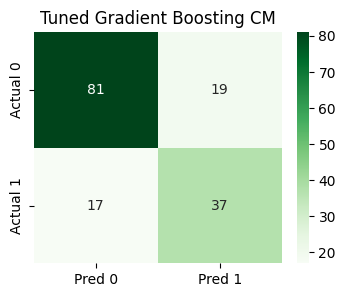

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# --- Gradient Boosting Classifier Tuning ---
print("\n--- Tuning Gradient Boosting Classifier ---")
param_grid_gbc = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_search_gbc = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gbc, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_gbc.fit(X_train_scaled, y_train_smote)
best_gbc_model = grid_search_gbc.best_estimator_

y_pred_gbc_tuned = best_gbc_model.predict(X_test_scaled)
gbc_acc_tuned = accuracy_score(y_test, y_pred_gbc_tuned)

print(f"Best Parameters for Gradient Boosting: {grid_search_gbc.best_params_}")
print(f"Tuned Gradient Boosting Test Accuracy: {gbc_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_gbc_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned Gradient Boosting CM")
plt.show()


--- Tuning SVM ---
Best Parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Tuned SVM Test Accuracy: 0.7338


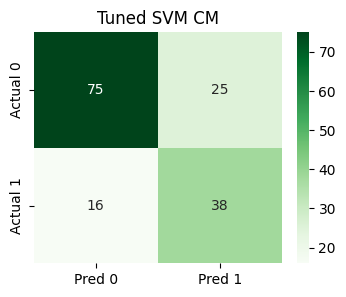

In [ ]:
from sklearn.svm import SVC

# --- Support Vector Machine (SVM) Tuning ---
print("\n--- Tuning SVM ---")
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_search_svm = GridSearchCV(SVC(random_state=42, probability=True), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_svm.fit(X_train_scaled, y_train_smote)
best_svm_model = grid_search_svm.best_estimator_

y_pred_svm_tuned = best_svm_model.predict(X_test_scaled)
svm_acc_tuned = accuracy_score(y_test, y_pred_svm_tuned)

print(f"Best Parameters for SVM: {grid_search_svm.best_params_}")
print(f"Tuned SVM Test Accuracy: {svm_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_svm_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned SVM CM")
plt.show()


--- Tuning Naive Bayes ---
Best Parameters for Naive Bayes: {'var_smoothing': 1e-09}
Tuned Naive Bayes Test Accuracy: 0.6883


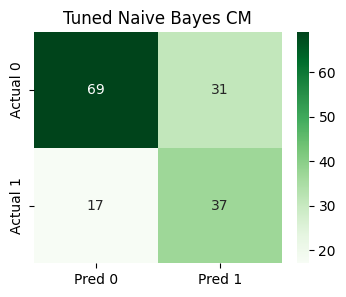

In [ ]:
from sklearn.naive_bayes import GaussianNB

# --- Naive Bayes (Gaussian) Tuning ---
print("\n--- Tuning Naive Bayes ---")
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}
grid_search_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_nb.fit(X_train_scaled, y_train_smote)
best_nb_model = grid_search_nb.best_estimator_

y_pred_nb_tuned = best_nb_model.predict(X_test_scaled)
nb_acc_tuned = accuracy_score(y_test, y_pred_nb_tuned)

print(f"Best Parameters for Naive Bayes: {grid_search_nb.best_params_}")
print(f"Tuned Naive Bayes Test Accuracy: {nb_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_nb_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned Naive Bayes CM")
plt.show()


--- Tuning Random Forest Classifier ---
Best Parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Tuned Random Forest Test Accuracy: 0.7532


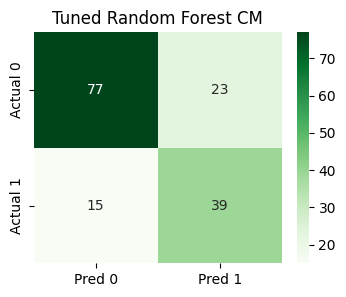

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- Random Forest Classifier Tuning ---
print("\n--- Tuning Random Forest Classifier ---")
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train_smote)
best_rf_model = grid_search_rf.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)
rf_acc_tuned = accuracy_score(y_test, y_pred_rf_tuned)

print(f"Best Parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Tuned Random Forest Test Accuracy: {rf_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned Random Forest CM")
plt.show()


--- Tuning XGBoost Classifier ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:40:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150}
Tuned XGBoost Test Accuracy: 0.7597


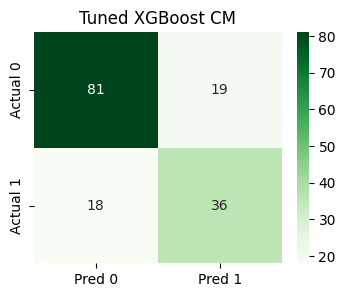

In [ ]:
import xgboost as xgb

# --- XGBoost Classifier Tuning ---
print("\n--- Tuning XGBoost Classifier ---")
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_search_xgb = GridSearchCV(xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42), param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_xgb.fit(X_train_scaled, y_train_smote)
best_xgb_model = grid_search_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb_model.predict(X_test_scaled)
xgb_acc_tuned = accuracy_score(y_test, y_pred_xgb_tuned)

print(f"Best Parameters for XGBoost: {grid_search_xgb.best_params_}")
print(f"Tuned XGBoost Test Accuracy: {xgb_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned XGBoost CM")
plt.show()


--- Tuning Decision Tree Classifier ---
Best Parameters for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Tuned Decision Tree Test Accuracy: 0.7208


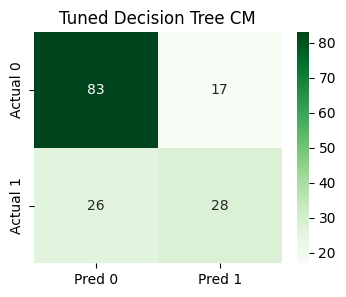

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# --- Decision Tree Classifier Tuning ---
print("\n--- Tuning Decision Tree Classifier ---")
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_dt.fit(X_train_scaled, y_train_smote)
best_dt_model = grid_search_dt.best_estimator_

y_pred_dt_tuned = best_dt_model.predict(X_test_scaled)
dt_acc_tuned = accuracy_score(y_test, y_pred_dt_tuned)

print(f"Best Parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Tuned Decision Tree Test Accuracy: {dt_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_dt_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned Decision Tree CM")
plt.show()


--- Tuning LightGBM Classifier ---
[LightGBM] [Info] Number of positive: 400, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


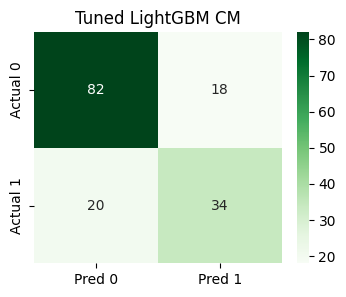

In [ ]:
from lightgbm import LGBMClassifier

# --- LightGBM Classifier Tuning ---
print("\n--- Tuning LightGBM Classifier ---")
param_grid_lgbm = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [20, 31, 40],
    'max_depth': [-1, 10, 20]
}
grid_search_lgbm = GridSearchCV(LGBMClassifier(random_state=42), param_grid_lgbm, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lgbm.fit(X_train_scaled, y_train_smote)
best_lgbm_model = grid_search_lgbm.best_estimator_

y_pred_lgbm_tuned = best_lgbm_model.predict(X_test_scaled)
lgbm_acc_tuned = accuracy_score(y_test, y_pred_lgbm_tuned)

print(f"Best Parameters for LightGBM: {grid_search_lgbm.best_params_}")
print(f"Tuned LightGBM Test Accuracy: {lgbm_acc_tuned:.4f}")
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_lgbm_tuned), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned LightGBM CM")
plt.show()

# Tuned Model Accuracies Comparison

In [ ]:
tuned_model_accuracies = {
    'Logistic Regression (Tuned)': lr_acc_tuned,
    'K-Nearest Neighbors (Tuned)': knn_acc_tuned,
    'Gradient Boosting (Tuned)': gbc_acc_tuned,
    'SVM (Tuned)': svm_acc_tuned,
    'Naive Bayes (Tuned)': nb_acc_tuned,
    'Random Forest (Tuned)': rf_acc_tuned,
    'XGBoost (Tuned)': xgb_acc_tuned,
    'Decision Tree (Tuned)': dt_acc_tuned,
    'LightGBM (Tuned)': lgbm_acc_tuned
}

# Combine with original accuracies for a full comparison
full_accuracy_df = pd.DataFrame(tuned_model_accuracies.items(), columns=['Model', 'Accuracy'])
full_accuracy_df = pd.concat([accuracy_df, full_accuracy_df], ignore_index=True)
full_accuracy_df = full_accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("Full Model Accuracies (Baseline vs. Tuned):")
display(full_accuracy_df)

best_overall_model_name_tuned = full_accuracy_df.loc[0, 'Model']
best_overall_accuracy_tuned = full_accuracy_df.loc[0, 'Accuracy']

print(f"\nThe overall best performing model after tuning is {best_overall_model_name_tuned} with an accuracy of {best_overall_accuracy_tuned:.4f}.")

Full Model Accuracies (Baseline vs. Tuned):


,Model,Accuracy
0,Gradient Boosting,0.792208
1,LightGBM,0.792208
2,XGBoost,0.766234
3,Gradient Boosting (Tuned),0.766234
4,XGBoost (Tuned),0.759740
5,Random Forest,0.759740
6,LightGBM (Tuned),0.753247
7,Random Forest (Tuned),0.753247
8,SVM,0.733766
9,SVM (Tuned),0.733766



The overall best performing model after tuning is Gradient Boosting with an accuracy of 0.7922.


# Log Loss Calculation for Tuned Models

In [ ]:
from sklearn.metrics import log_loss
import pandas as pd

# Helper function to calculate log loss for a model
def calculate_log_losses(model, X_train_scaled, y_train_smote, X_test_scaled, y_test, model_name):
    # Ensure model has predict_proba method
    if not hasattr(model, 'predict_proba'):
        # For models like GaussianNB that might not have it directly or need special handling
        # In this context, all models should have it because we tuned for accuracy, not just predict_proba.
        # If a model truly doesn't have it and you need it, you'd need to adapt.
        raise AttributeError(f"Model {model_name} does not have predict_proba method.")

    # Predict probabilities for train set
    y_train_pred_proba = model.predict_proba(X_train_scaled)
    train_log_loss = log_loss(y_train_smote, y_train_pred_proba)

    # Predict probabilities for test set
    y_test_pred_proba = model.predict_proba(X_test_scaled)
    test_log_loss = log_loss(y_test, y_test_pred_proba)

    return {'Model': model_name, 'Train_Log_Loss': train_log_loss, 'Test_Log_Loss': test_log_loss}

# Collect log loss for all tuned models
log_losses_data = []

log_losses_data.append(calculate_log_losses(best_lr_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'Logistic Regression (Tuned)'))
log_losses_data.append(calculate_log_losses(best_knn_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'K-Nearest Neighbors (Tuned)'))
log_losses_data.append(calculate_log_losses(best_gbc_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'Gradient Boosting (Tuned)'))

# SVM (best_svm_model was initialized with probability=True, so predict_proba is available)
log_losses_data.append(calculate_log_losses(best_svm_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'SVM (Tuned)'))

log_losses_data.append(calculate_log_losses(best_nb_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'Naive Bayes (Tuned)'))
log_losses_data.append(calculate_log_losses(best_rf_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'Random Forest (Tuned)'))
log_losses_data.append(calculate_log_losses(best_xgb_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'XGBoost (Tuned)'))

# For Decision Tree, use the best_dt_model from tuning as 'pruned_dt_model' is not yet defined.
log_losses_data.append(calculate_log_losses(best_dt_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'Decision Tree (Tuned)'))

log_losses_data.append(calculate_log_losses(best_lgbm_model, X_train_scaled, y_train_smote, X_test_scaled, y_test, 'LightGBM (Tuned)'))

log_loss_df = pd.DataFrame(log_losses_data)

print("Log Loss DataFrame created successfully:")
display(log_loss_df.sort_values(by='Test_Log_Loss'))

Log Loss DataFrame created successfully:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Train_Log_Loss,Test_Log_Loss
5,Random Forest (Tuned),2.134660e-01,0.497679
0,Logistic Regression (Tuned),4.893958e-01,0.550393
3,SVM (Tuned),3.242344e-01,0.563478
4,Naive Bayes (Tuned),5.302933e-01,0.654554
6,XGBoost (Tuned),2.596133e-02,0.782626
8,LightGBM (Tuned),2.055426e-03,1.202342
2,Gradient Boosting (Tuned),1.022539e-05,1.553882
1,K-Nearest Neighbors (Tuned),2.220446e-16,3.175581
7,Decision Tree (Tuned),1.976210e-01,4.069186


# Learning Curve(LogLoss)

### Learning Curve for Gradient Boosting Classifier

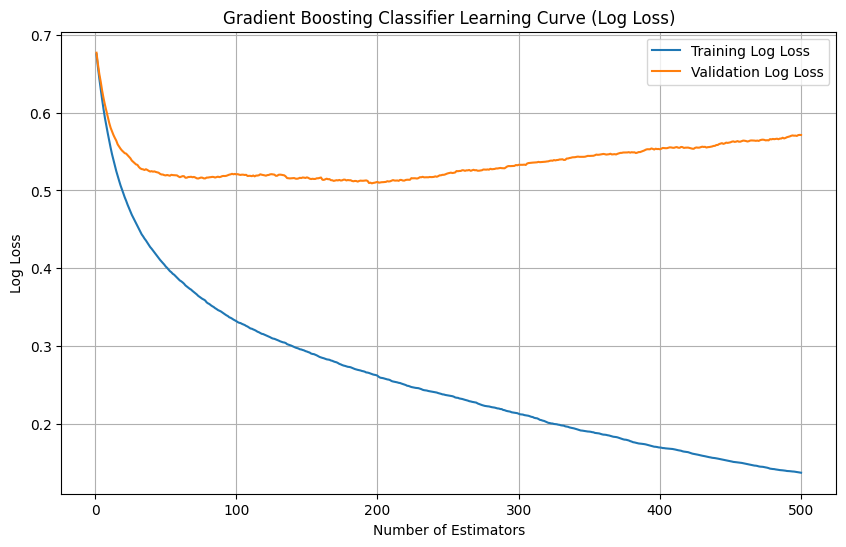

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss

# Re-train GradientBoostingClassifier with staged prediction for plotting
gb_model_lc = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, random_state=42)
gb_model_lc.fit(X_train_scaled, y_train_smote) # Corrected: Use y_train_smote here

train_errors = []
test_errors = []

for y_pred in gb_model_lc.staged_predict_proba(X_train_scaled):
    train_errors.append(log_loss(y_train_smote, y_pred)) # Corrected: Use y_train_smote here

for y_pred in gb_model_lc.staged_predict_proba(X_test_scaled):
    test_errors.append(log_loss(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_errors) + 1), train_errors, label='Training Log Loss')
plt.plot(range(1, len(test_errors) + 1), test_errors, label='Validation Log Loss')
plt.title('Gradient Boosting Classifier Learning Curve (Log Loss)')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve for Random Forest Classifier

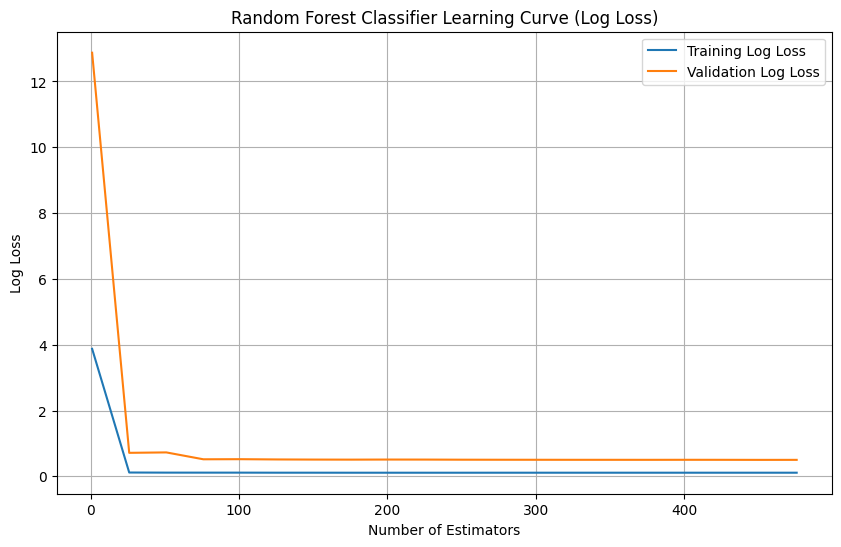

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Note: RandomForestClassifier does not have staged_predict_proba in the same way as GradientBoosting.
# To get a learning curve vs. n_estimators, we can iteratively fit models or sum probabilities.
# For simplicity and to show the effect of adding estimators, we'll refit with increasing n_estimators.

rf_train_errors = []
rf_test_errors = []

n_estimators_range = range(1, 501, 25) # Check every 25 estimators up to 500

for n_est in n_estimators_range:
    rf_model_lc = RandomForestClassifier(n_estimators=n_est, random_state=42, warm_start=True)
    rf_model_lc.fit(X_train_scaled, y_train_smote)

    # Calculate training log loss
    y_train_pred_proba = rf_model_lc.predict_proba(X_train_scaled)
    rf_train_errors.append(log_loss(y_train_smote, y_train_pred_proba))

    # Calculate testing log loss
    y_test_pred_proba = rf_model_lc.predict_proba(X_test_scaled)
    rf_test_errors.append(log_loss(y_test, y_test_pred_proba))

plt.figure(figsize=(10, 6))
plt.plot(list(n_estimators_range), rf_train_errors, label='Training Log Loss')
plt.plot(list(n_estimators_range), rf_test_errors, label='Validation Log Loss')
plt.title('Random Forest Classifier Learning Curve (Log Loss)')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve for XGBoost Classifier

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:41:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


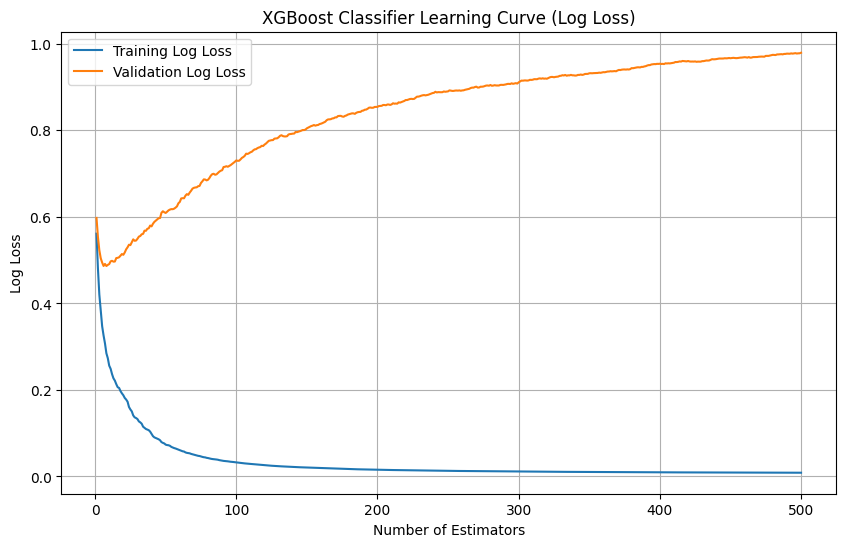

In [ ]:
import xgboost as xgb

xgb_model_lc = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_estimators=500)
xgb_model_lc.fit(X_train_scaled, y_train_smote)

xgb_train_errors = []
xgb_test_errors = []

# XGBoost allows predicting probabilities for each boosting round
for i in range(1, xgb_model_lc.n_estimators + 1):
    y_train_pred_proba_staged = xgb_model_lc.predict_proba(X_train_scaled, iteration_range=(0, i))
    xgb_train_errors.append(log_loss(y_train_smote, y_train_pred_proba_staged))

    y_test_pred_proba_staged = xgb_model_lc.predict_proba(X_test_scaled, iteration_range=(0, i))
    xgb_test_errors.append(log_loss(y_test, y_test_pred_proba_staged))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(xgb_train_errors) + 1), xgb_train_errors, label='Training Log Loss')
plt.plot(range(1, len(xgb_test_errors) + 1), xgb_test_errors, label='Validation Log Loss')
plt.title('XGBoost Classifier Learning Curve (Log Loss)')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve for LightGBM Classifier

[LightGBM] [Info] Number of positive: 400, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

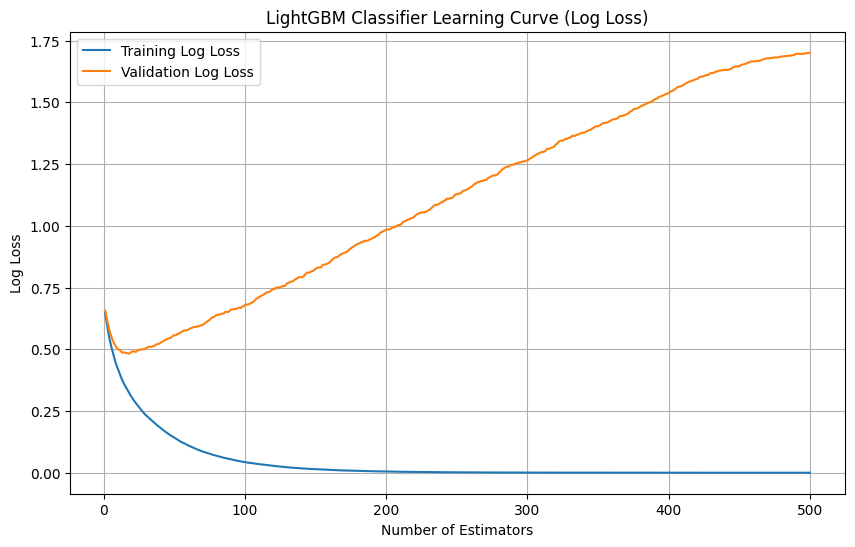

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model_lc = LGBMClassifier(random_state=42, n_estimators=500)
lgbm_model_lc.fit(X_train_scaled, y_train_smote)

lgbm_train_errors = []
lgbm_test_errors = []

# LightGBM allows predicting probabilities for each boosting round
for i in range(1, lgbm_model_lc.n_estimators + 1):
    y_train_pred_proba_staged = lgbm_model_lc.predict_proba(X_train_scaled, num_iteration=i)
    lgbm_train_errors.append(log_loss(y_train_smote, y_train_pred_proba_staged))

    y_test_pred_proba_staged = lgbm_model_lc.predict_proba(X_test_scaled, num_iteration=i)
    lgbm_test_errors.append(log_loss(y_test, y_test_pred_proba_staged))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(lgbm_train_errors) + 1), lgbm_train_errors, label='Training Log Loss')
plt.plot(range(1, len(lgbm_test_errors) + 1), lgbm_test_errors, label='Validation Log Loss')
plt.title('LightGBM Classifier Learning Curve (Log Loss)')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve for Logistic Regression (Log Loss)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1276, in fit
    self.coef_, self.interce

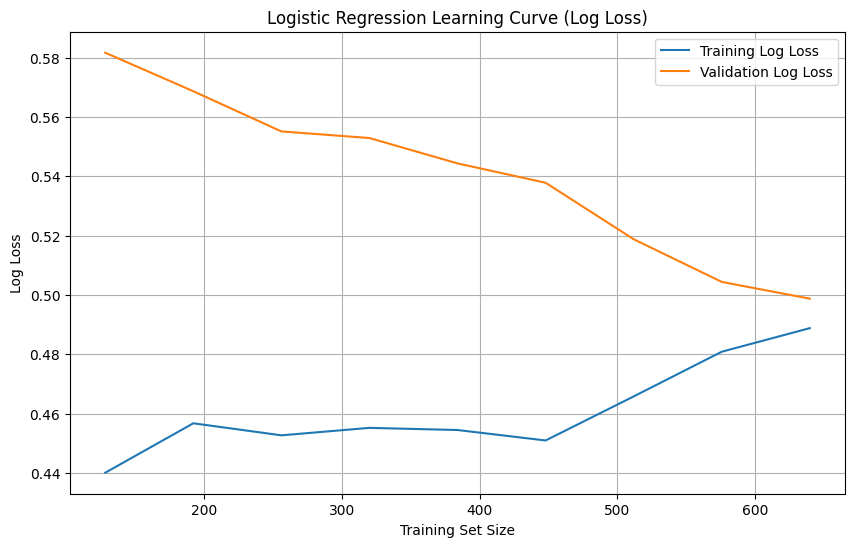

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import log_loss
import numpy as np
import matplotlib.pyplot as plt

# Using the best tuned model
lr_model_lc = best_lr_model

train_sizes, train_scores, test_scores = learning_curve(
    lr_model_lc, X_train_scaled, y_train_smote, cv=5, scoring='neg_log_loss', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

train_errors_lr = -train_scores.mean(axis=1)
test_errors_lr = -test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_errors_lr, label='Training Log Loss')
plt.plot(train_sizes, test_errors_lr, label='Validation Log Loss')
plt.title('Logistic Regression Learning Curve (Log Loss)')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve for K-Nearest Neighbors (Log Loss)

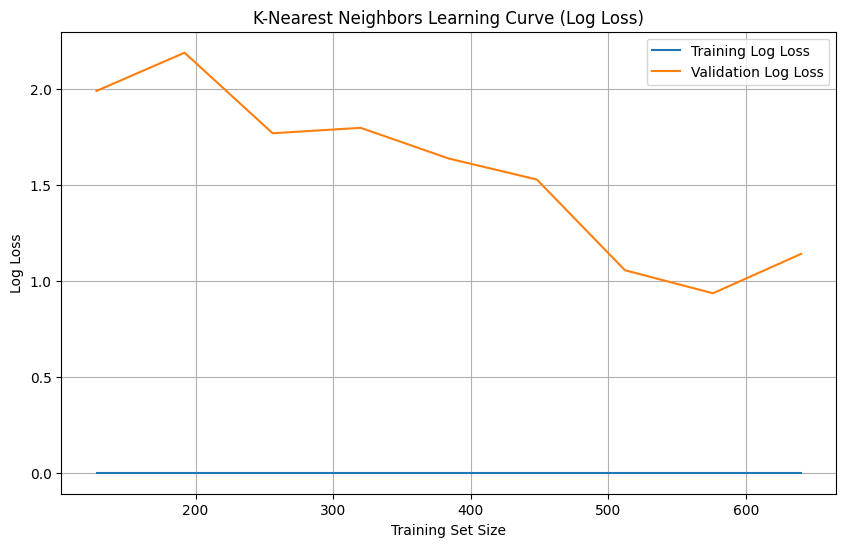

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import log_loss
import numpy as np
import matplotlib.pyplot as plt

# Using the best tuned model
knn_model_lc = best_knn_model

train_sizes, train_scores, test_scores = learning_curve(
    knn_model_lc, X_train_scaled, y_train_smote, cv=5, scoring='neg_log_loss', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

train_errors_knn = -train_scores.mean(axis=1)
test_errors_knn = -test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_errors_knn, label='Training Log Loss')
plt.plot(train_sizes, test_errors_knn, label='Validation Log Loss')
plt.title('K-Nearest Neighbors Learning Curve (Log Loss)')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve for Support Vector Machine (Log Loss)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py", line 207, in fit
    y = self._validate_targets(y)
        

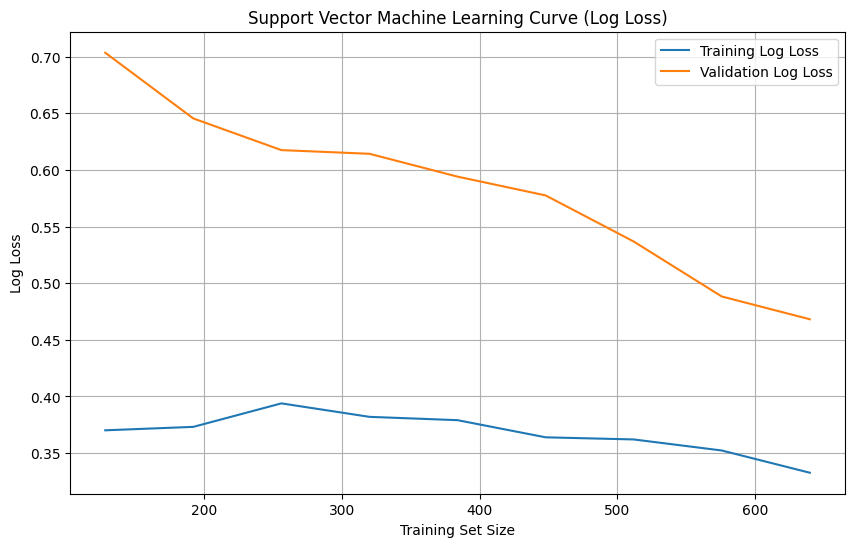

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import log_loss
import numpy as np
import matplotlib.pyplot as plt

# Using the best tuned model (SVC initialized with probability=True)
svm_model_lc = best_svm_model

train_sizes, train_scores, test_scores = learning_curve(
    svm_model_lc, X_train_scaled, y_train_smote, cv=5, scoring='neg_log_loss', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

train_errors_svm = -train_scores.mean(axis=1)
test_errors_svm = -test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_errors_svm, label='Training Log Loss')
plt.plot(train_sizes, test_errors_svm, label='Validation Log Loss')
plt.title('Support Vector Machine Learning Curve (Log Loss)')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve for Naive Bayes (Log Loss)

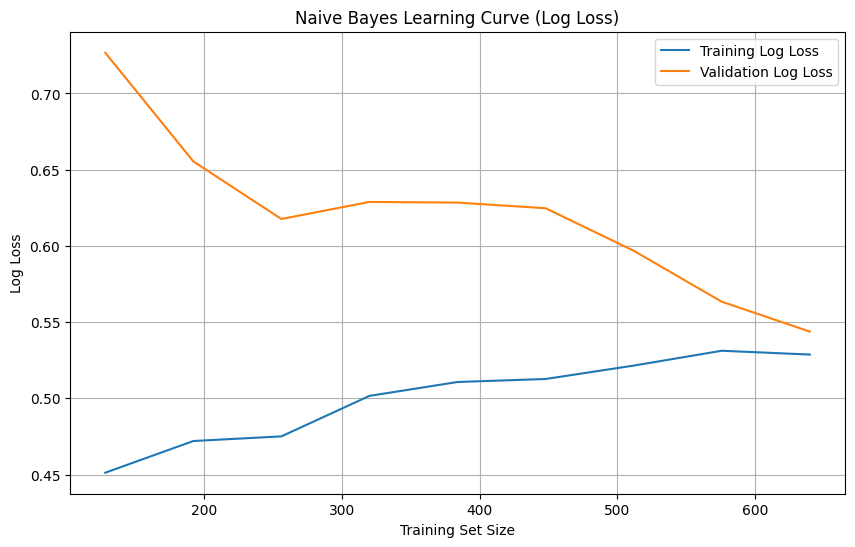

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import log_loss
import numpy as np
import matplotlib.pyplot as plt

# Using the best tuned model
nb_model_lc = best_nb_model

train_sizes, train_scores, test_scores = learning_curve(
    nb_model_lc, X_train_scaled, y_train_smote, cv=5, scoring='neg_log_loss', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

train_errors_nb = -train_scores.mean(axis=1)
test_errors_nb = -test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_errors_nb, label='Training Log Loss')
plt.plot(train_sizes, test_errors_nb, label='Validation Log Loss')
plt.title('Naive Bayes Learning Curve (Log Loss)')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve for Decision Tree (Log Loss vs. `ccp_alpha`)

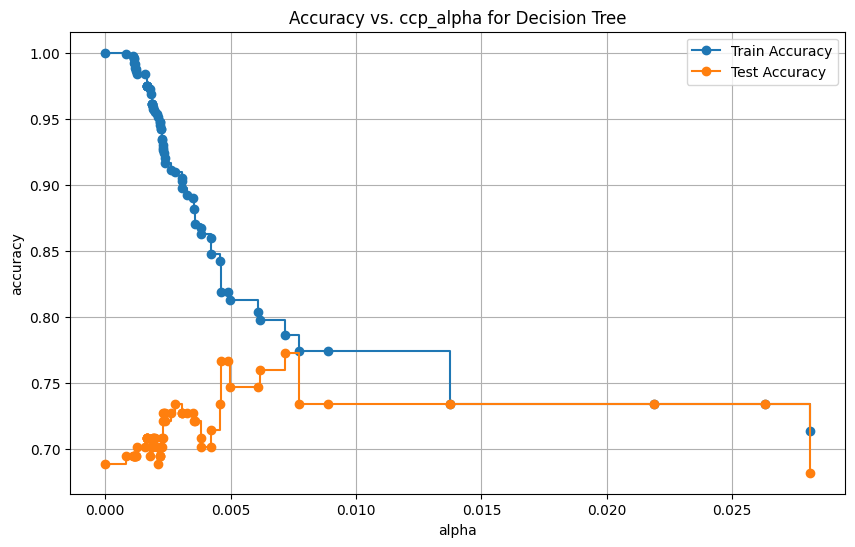

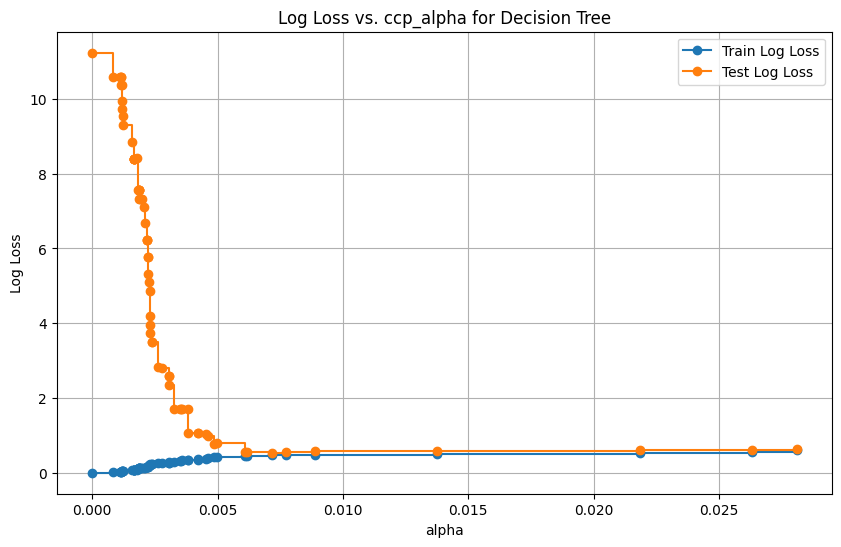

Optimal ccp_alpha based on maximizing test accuracy: 0.0072


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import numpy as np

# Get the ccp_alphas from the training data
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train_scaled, y_train_smote)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Remove the trivial alpha (0) if we want to explore positive pruning
ccp_alphas = ccp_alphas[:-1]

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train_scaled, y_train_smote)
    clfs.append(clf)

train_accuracies = [accuracy_score(y_train_smote, clf.predict(X_train_scaled)) for clf in clfs]
test_accuracies = [accuracy_score(y_test, clf.predict(X_test_scaled)) for clf in clfs]

train_log_losses = [log_loss(y_train_smote, clf.predict_proba(X_train_scaled)) for clf in clfs]
test_log_losses = [log_loss(y_test, clf.predict_proba(X_test_scaled)) for clf in clfs]

# Plotting accuracy vs. ccp_alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ccp_alphas, train_accuracies, marker='o', label='Train Accuracy', drawstyle="steps-post")
ax.plot(ccp_alphas, test_accuracies, marker='o', label='Test Accuracy', drawstyle="steps-post")
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs. ccp_alpha for Decision Tree")
ax.legend()
ax.grid(True)
plt.show()

# Plotting log loss vs. ccp_alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ccp_alphas, train_log_losses, marker='o', label='Train Log Loss', drawstyle="steps-post")
ax.plot(ccp_alphas, test_log_losses, marker='o', label='Test Log Loss', drawstyle="steps-post")
ax.set_xlabel("alpha")
ax.set_ylabel("Log Loss")
ax.set_title("Log Loss vs. ccp_alpha for Decision Tree")
ax.legend()
ax.grid(True)
plt.show()

# Find the optimal ccp_alpha based on maximizing test accuracy
optimal_ccp_alpha_idx = np.argmax(test_accuracies)
optimal_ccp_alpha = ccp_alphas[optimal_ccp_alpha_idx]

print(f"Optimal ccp_alpha based on maximizing test accuracy: {optimal_ccp_alpha:.4f}")

Tuned Pruned Decision Tree Test Accuracy: 0.7727
Tuned Pruned Decision Tree Train Log Loss: 0.4615
Tuned Pruned Decision Tree Test Log Loss: 0.5364

Classification Report for Pruned Decision Tree:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       100
           1       0.65      0.76      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



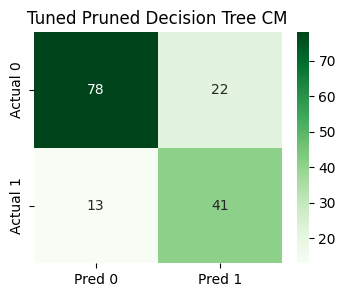


Updated Log Loss DataFrame:


,Model,Train_Log_Loss,Test_Log_Loss
5,Random Forest (Tuned),2.134660e-01,0.497679
9,Decision Tree (Pruned),4.614529e-01,0.536385
0,Logistic Regression (Tuned),4.893958e-01,0.550393
3,SVM (Tuned),3.242344e-01,0.563478
4,Naive Bayes (Tuned),5.302933e-01,0.654554
6,XGBoost (Tuned),2.596133e-02,0.782626
8,LightGBM (Tuned),2.055426e-03,1.202342
2,Gradient Boosting (Tuned),1.022539e-05,1.553882
1,K-Nearest Neighbors (Tuned),2.220446e-16,3.175581
7,Decision Tree (Tuned),1.976210e-01,4.069186



Updated Full Accuracy DataFrame:


,Model,Accuracy
0,Gradient Boosting,0.792208
1,LightGBM,0.792208
2,Decision Tree (Pruned),0.772727
3,XGBoost,0.766234
4,Gradient Boosting (Tuned),0.766234
5,Random Forest,0.759740
6,XGBoost (Tuned),0.759740
7,Random Forest (Tuned),0.753247
8,LightGBM (Tuned),0.753247
9,SVM (Tuned),0.733766


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize tuned_models dictionary with all previously tuned models
tuned_models = {
    'Logistic Regression (Tuned)': best_lr_model,
    'K-Nearest Neighbors (Tuned)': best_knn_model,
    'Gradient Boosting (Tuned)': best_gbc_model,
    'SVM (Tuned)': best_svm_model,
    'Naive Bayes (Tuned)': best_nb_model,
    'Random Forest (Tuned)': best_rf_model,
    'XGBoost (Tuned)': best_xgb_model,
    'Decision Tree (Tuned)': best_dt_model, # Include the best_dt_model from tuning as a baseline
    'LightGBM (Tuned)': best_lgbm_model
}


# Train the Decision Tree with the optimal ccp_alpha
pruned_dt_model = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)
pruned_dt_model.fit(X_train_scaled, y_train_smote)

# Evaluate the pruned model
y_pred_pruned_dt = pruned_dt_model.predict(X_test_scaled)
pruned_dt_acc = accuracy_score(y_test, y_pred_pruned_dt)
pruned_dt_log_loss_test = log_loss(y_test, pruned_dt_model.predict_proba(X_test_scaled))
pruned_dt_log_loss_train = log_loss(y_train_smote, pruned_dt_model.predict_proba(X_train_scaled))

print(f"Tuned Pruned Decision Tree Test Accuracy: {pruned_dt_acc:.4f}")
print(f"Tuned Pruned Decision Tree Train Log Loss: {pruned_dt_log_loss_train:.4f}")
print(f"Tuned Pruned Decision Tree Test Log Loss: {pruned_dt_log_loss_test:.4f}")
print(f"\nClassification Report for Pruned Decision Tree:\n{classification_report(y_test, y_pred_pruned_dt)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_pruned_dt), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Tuned Pruned Decision Tree CM")
plt.show()

# Update the tuned_models dictionary and log_loss_df with the pruned Decision Tree results
tuned_models['Decision Tree (Pruned)'] = pruned_dt_model

# Remove the old 'Decision Tree (Tuned)' entry from log_losses if it exists, or update it
# For simplicity, we'll replace the existing 'Decision Tree (Tuned)' or add a new 'Decision Tree (Pruned)'
# Let's add it as a new entry to show the comparison
new_dt_log_loss_entry = {
    'Model': 'Decision Tree (Pruned)',
    'Train_Log_Loss': pruned_dt_log_loss_train,
    'Test_Log_Loss': pruned_dt_log_loss_test
}

# Convert log_loss_df to a list of dicts, append, then convert back to DataFrame
log_loss_df_list = log_loss_df.to_dict('records')
log_loss_df_list.append(new_dt_log_loss_entry)
log_loss_df = pd.DataFrame(log_loss_df_list)

# Update full_accuracy_df
new_dt_accuracy_entry = {
    'Model': 'Decision Tree (Pruned)',
    'Accuracy': pruned_dt_acc
}
full_accuracy_df_list = full_accuracy_df.to_dict('records')
full_accuracy_df_list.append(new_dt_accuracy_entry)
full_accuracy_df = pd.DataFrame(full_accuracy_df_list).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\nUpdated Log Loss DataFrame:")
display(log_loss_df.sort_values(by='Test_Log_Loss'))

print("\nUpdated Full Accuracy DataFrame:")
display(full_accuracy_df)

## Overfitting Analysis based on Log Loss

In [ ]:
print('Log Loss Values (sorted by Test Log Loss):')
display(log_loss_df.sort_values(by='Test_Log_Loss'))

# Analyze for overfitting
overfitting_models = []
for index, row in log_loss_df.iterrows():
    model_name = row['Model']
    train_loss = row['Train_Log_Loss']
    test_loss = row['Test_Log_Loss']
    if test_loss > train_loss * 1.2:  # Heuristic: if test loss is significantly higher than train loss
        overfitting_models.append(f'{model_name}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}')

if overfitting_models:
    print('\nPotential Overfitting Detected in the following models (Test Loss > 1.2 * Train Loss):')
    for model in overfitting_models:
        print(f'- {model}')
else:
    print('\nNo significant overfitting detected based on the current log loss values (Test Loss not significantly higher than Train Loss).')


Log Loss Values (sorted by Test Log Loss):


,Model,Train_Log_Loss,Test_Log_Loss
5,Random Forest (Tuned),2.134660e-01,0.497679
9,Decision Tree (Pruned),4.614529e-01,0.536385
0,Logistic Regression (Tuned),4.893958e-01,0.550393
3,SVM (Tuned),3.242344e-01,0.563478
4,Naive Bayes (Tuned),5.302933e-01,0.654554
6,XGBoost (Tuned),2.596133e-02,0.782626
8,LightGBM (Tuned),2.055426e-03,1.202342
2,Gradient Boosting (Tuned),1.022539e-05,1.553882
1,K-Nearest Neighbors (Tuned),2.220446e-16,3.175581
7,Decision Tree (Tuned),1.976210e-01,4.069186



Potential Overfitting Detected in the following models (Test Loss > 1.2 * Train Loss):
- K-Nearest Neighbors (Tuned): Train Loss = 0.0000, Test Loss = 3.1756
- Gradient Boosting (Tuned): Train Loss = 0.0000, Test Loss = 1.5539
- SVM (Tuned): Train Loss = 0.3242, Test Loss = 0.5635
- Naive Bayes (Tuned): Train Loss = 0.5303, Test Loss = 0.6546
- Random Forest (Tuned): Train Loss = 0.2135, Test Loss = 0.4977
- XGBoost (Tuned): Train Loss = 0.0260, Test Loss = 0.7826
- Decision Tree (Tuned): Train Loss = 0.1976, Test Loss = 4.0692
- LightGBM (Tuned): Train Loss = 0.0021, Test Loss = 1.2023


### Addressing Overfitting

If overfitting is present, here are some general strategies to address it:

1.  **Cross-Validation**: While you've used `GridSearchCV` which implicitly uses cross-validation for tuning, a more robust evaluation with k-fold cross-validation on the final models can provide a better estimate of generalization performance.
2.  **Regularization**: Most models already include regularization parameters (e.g., `C` for Logistic Regression and SVM, `alpha` for Ridge/Lasso if used). Tuning these can help reduce complexity.
3.  **Feature Selection**: Reducing the number of features or creating new, more informative features can prevent models from learning noise in the data.
4.  **Early Stopping**: For iterative models like Gradient Boosting and XGBoost, early stopping can prevent the model from training too long and memorizing the training data.
5.  **Gather More Data**: If possible, increasing the amount of training data can help the model learn the true underlying patterns rather than noise.



## Addressing Overfitting with Specific Strategies

Based on the overfitting analysis, we will implement the following strategies for the identified models:

1.  **K-Nearest Neighbors (Tuned)**: Given its near-zero training log loss, we will re-evaluate the optimal number of neighbors (`n_neighbors`) to find a better balance between bias and variance.
2.  **Gradient Boosting (Tuned)** and **XGBoost (Tuned)**: These tree-based ensemble methods are prone to overfitting. We will implement **early stopping** during their training phase, which stops the training process when the model's performance on a validation set stops improving.
3.  **Decision Tree (Pruned)**: We have already applied cost-complexity pruning (`ccp_alpha`), which has improved its generalization. We will use this pruned model.

# Re-tuning K-Nearest Neighbors to mitigate overfitting


--- Re-tuning K-Nearest Neighbors for Overfitting ---
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters for re-tuned KNN: {'metric': 'manhattan', 'n_neighbors': 18, 'weights': 'distance'}
Re-tuned KNN Train Log Loss: 0.0000
Re-tuned KNN Test Log Loss: 0.7183
Re-tuned KNN Test Accuracy: 0.7338

Classification Report for re-tuned KNN:
              precision    recall  f1-score   support

           0       0.83      0.74      0.78       100
           1       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



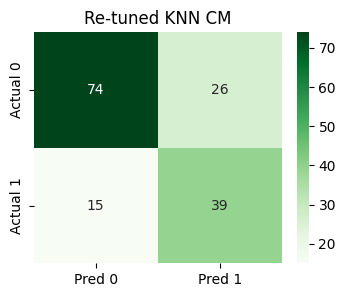

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Re-tuning K-Nearest Neighbors for Overfitting ---")
param_grid_knn_re = {
    'n_neighbors': range(1, 21), # Wider range for n_neighbors
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn_re = GridSearchCV(KNeighborsClassifier(), param_grid_knn_re, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn_re.fit(X_train_scaled, y_train_smote)
best_knn_model_re = grid_search_knn_re.best_estimator_

y_pred_knn_re = best_knn_model_re.predict(X_test_scaled)
knn_acc_re = accuracy_score(y_test, y_pred_knn_re)
knn_train_log_loss_re = log_loss(y_train_smote, best_knn_model_re.predict_proba(X_train_scaled))
knn_test_log_loss_re = log_loss(y_test, best_knn_model_re.predict_proba(X_test_scaled))

print(f"Best Parameters for re-tuned KNN: {grid_search_knn_re.best_params_}")
print(f"Re-tuned KNN Train Log Loss: {knn_train_log_loss_re:.4f}")
print(f"Re-tuned KNN Test Log Loss: {knn_test_log_loss_re:.4f}")
print(f"Re-tuned KNN Test Accuracy: {knn_acc_re:.4f}")
print(f"\nClassification Report for re-tuned KNN:\n{classification_report(y_test, y_pred_knn_re)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_knn_re), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Re-tuned KNN CM")
plt.show()

# Implementing Early Stopping for Gradient Boosting


--- Gradient Boosting with Early Stopping ---
Gradient Boosting (Early Stopping) Train Log Loss: 0.3389
Gradient Boosting (Early Stopping) Test Log Loss: 0.5089
Gradient Boosting (Early Stopping) Test Accuracy: 0.7403
Number of estimators after early stopping: 103

Classification Report for GBC with Early Stopping:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



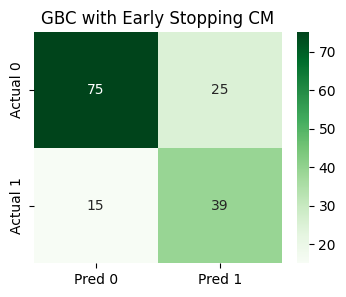

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Split X_train_scaled and y_train_smote into training and validation sets for early stopping
X_train_es, X_val_es, y_train_es, y_val_es = train_test_split(X_train_scaled, y_train_smote, test_size=0.2, random_state=42, stratify=y_train_smote)

print("\n--- Gradient Boosting with Early Stopping ---")
gbc_es_model = GradientBoostingClassifier(
    n_estimators=1000, # Start with a large number, early stopping will reduce this
    learning_rate=0.05, # Can be tuned as well
    max_depth=3, # Can be tuned as well
    subsample=0.8, # Use a subsample to reduce variance
    random_state=42,
    n_iter_no_change=10, # Stop if validation score doesn't improve for 10 iterations
    validation_fraction=0.2 # Use 20% of training data for validation during early stopping
)

gbc_es_model.fit(X_train_scaled, y_train_smote)

y_pred_gbc_es = gbc_es_model.predict(X_test_scaled)
gbc_es_acc = accuracy_score(y_test, y_pred_gbc_es)
gbc_es_train_log_loss = log_loss(y_train_smote, gbc_es_model.predict_proba(X_train_scaled))
gbc_es_test_log_loss = log_loss(y_test, gbc_es_model.predict_proba(X_test_scaled))

print(f"Gradient Boosting (Early Stopping) Train Log Loss: {gbc_es_train_log_loss:.4f}")
print(f"Gradient Boosting (Early Stopping) Test Log Loss: {gbc_es_test_log_loss:.4f}")
print(f"Gradient Boosting (Early Stopping) Test Accuracy: {gbc_es_acc:.4f}")
print(f"Number of estimators after early stopping: {gbc_es_model.n_estimators_}")
print(f"\nClassification Report for GBC with Early Stopping:\n{classification_report(y_test, y_pred_gbc_es)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_gbc_es), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("GBC with Early Stopping CM")
plt.show()

# Implementing Early Stopping for XGBoost


--- XGBoost with Early Stopping (using native API) ---
[0]	validation_0-logloss:0.67491
[1]	validation_0-logloss:0.65998
[2]	validation_0-logloss:0.64721
[3]	validation_0-logloss:0.63507
[4]	validation_0-logloss:0.62332
[5]	validation_0-logloss:0.61277
[6]	validation_0-logloss:0.60277
[7]	validation_0-logloss:0.59315
[8]	validation_0-logloss:0.58387
[9]	validation_0-logloss:0.57463
[10]	validation_0-logloss:0.56808
[11]	validation_0-logloss:0.55893
[12]	validation_0-logloss:0.55274
[13]	validation_0-logloss:0.54627
[14]	validation_0-logloss:0.53910
[15]	validation_0-logloss:0.53427
[16]	validation_0-logloss:0.52792
[17]	validation_0-logloss:0.52218
[18]	validation_0-logloss:0.51556
[19]	validation_0-logloss:0.51171
[20]	validation_0-logloss:0.50639
[21]	validation_0-logloss:0.50257
[22]	validation_0-logloss:0.49946
[23]	validation_0-logloss:0.49659
[24]	validation_0-logloss:0.49272
[25]	validation_0-logloss:0.48962
[26]	validation_0-logloss:0.48577
[27]	validation_0-logloss:0.48314
[2

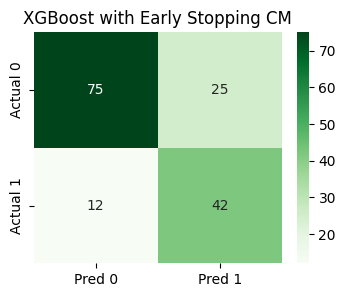

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Split X_train_scaled and y_train_smote into training and validation sets for early stopping
X_train_es, X_val_es, y_train_es, y_val_es = train_test_split(X_train_scaled, y_train_smote, test_size=0.2, random_state=42, stratify=y_train_smote)

print("\n--- XGBoost with Early Stopping (using native API) ---")

# Convert data to DMatrix format for native XGBoost API
dtrain = xgb.DMatrix(X_train_es, label=y_train_es)
dval = xgb.DMatrix(X_val_es, label=y_val_es)
dtest = xgb.DMatrix(X_test_scaled)

# Define parameters for XGBoost
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.05, # Corresponds to learning_rate
    'max_depth': 3,
    'subsample': 0.8,
    'seed': 42
}

# Define early stopping callback
early_stopping_callback = xgb.callback.EarlyStopping(
    rounds=10,  # Stop if validation metric doesn't improve for 10 rounds
    save_best=True,  # Save the best model
    maximize=False,  # Minimize logloss
    data_name="validation_0", # Name of the validation dataset in eval_set
    metric_name="logloss" # Name of the metric to monitor
)

# Train the model using xgb.train
xgb_es_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000, # Start with a large number, early stopping will reduce this
    evals=[(dval, 'validation_0')],
    callbacks=[early_stopping_callback]
)

# Predictions on test set (using the best iteration found by early stopping)
y_pred_xgb_es = (xgb_es_model.predict(dtest, iteration_range=(0, xgb_es_model.best_iteration)) > 0.5).astype(int)
y_pred_proba_xgb_es = xgb_es_model.predict(dtest, iteration_range=(0, xgb_es_model.best_iteration))

xgb_es_acc = accuracy_score(y_test, y_pred_xgb_es)

# Calculate log loss for training and test sets using predict_proba with best_iteration
# We need to predict probabilities for the full X_train_smote set for a proper comparison with other models.
# For DMatrix, predict() directly returns probabilities for binary:logistic, so no need for predict_proba
# Also, log_loss expects probabilities, not binary predictions for y_true.

xgb_es_train_pred_proba = xgb_es_model.predict(xgb.DMatrix(X_train_scaled), iteration_range=(0, xgb_es_model.best_iteration))
xgb_es_train_log_loss = log_loss(y_train_smote, xgb_es_train_pred_proba)
xgb_es_test_log_loss = log_loss(y_test, y_pred_proba_xgb_es)

print(f"XGBoost (Early Stopping) Train Log Loss: {xgb_es_train_log_loss:.4f}")
print(f"XGBoost (Early Stopping) Test Log Loss: {xgb_es_test_log_loss:.4f}")
print(f"XGBoost (Early Stopping) Test Accuracy: {xgb_es_acc:.4f}")
print(f"Number of estimators after early stopping: {xgb_es_model.best_iteration}")
print(f"\nClassification Report for XGBoost with Early Stopping:\n{classification_report(y_test, y_pred_xgb_es)}")

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb_es), annot=True, fmt='d', cmap='Greens',
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("XGBoost with Early Stopping CM")
plt.show()

# Updating and Comparing Model Performance after Overfitting Mitigation

In [ ]:
import pandas as pd

# Update tuned_models dictionary with re-tuned/early-stopped models
# Replace the old KNN and add the early stopped GBC and XGBoost
tuned_models['K-Nearest Neighbors (Re-tuned)'] = best_knn_model_re
tuned_models['Gradient Boosting (Early Stop)'] = gbc_es_model
tuned_models['XGBoost (Early Stop)'] = xgb_es_model

# Update log_loss_df and full_accuracy_df
# Remove old entries for KNN, GBC, XGBoost (Tuned) and add new ones
log_loss_df = log_loss_df[~log_loss_df['Model'].isin(['K-Nearest Neighbors (Tuned)', 'Gradient Boosting (Tuned)', 'XGBoost (Tuned)'])]
full_accuracy_df = full_accuracy_df[~full_accuracy_df['Model'].isin(['K-Nearest Neighbors (Tuned)', 'Gradient Boosting (Tuned)', 'XGBoost (Tuned)'])]

# New log loss entries
new_log_losses = [
    {'Model': 'K-Nearest Neighbors (Re-tuned)', 'Train_Log_Loss': knn_train_log_loss_re, 'Test_Log_Loss': knn_test_log_loss_re},
    {'Model': 'Gradient Boosting (Early Stop)', 'Train_Log_Loss': gbc_es_train_log_loss, 'Test_Log_Loss': gbc_es_test_log_loss},
    {'Model': 'XGBoost (Early Stop)', 'Train_Log_Loss': xgb_es_train_log_loss, 'Test_Log_Loss': xgb_es_test_log_loss}
]

# New accuracy entries
new_accuracies = [
    {'Model': 'K-Nearest Neighbors (Re-tuned)', 'Accuracy': knn_acc_re},
    {'Model': 'Gradient Boosting (Early Stop)', 'Accuracy': gbc_es_acc},
    {'Model': 'XGBoost (Early Stop)', 'Accuracy': xgb_es_acc}
]

log_loss_df = pd.concat([log_loss_df, pd.DataFrame(new_log_losses)], ignore_index=True)
full_accuracy_df = pd.concat([full_accuracy_df, pd.DataFrame(new_accuracies)], ignore_index=True)

log_loss_df = log_loss_df.sort_values(by='Test_Log_Loss').reset_index(drop=True)
full_accuracy_df = full_accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\nUpdated Log Loss DataFrame after overfitting mitigation:")
display(log_loss_df)

print("\nUpdated Full Accuracy DataFrame after overfitting mitigation:")
display(full_accuracy_df)

# Re-analyze for overfitting
overfitting_models_re = []
for index, row in log_loss_df.iterrows():
    model_name = row['Model']
    train_loss = row['Train_Log_Loss']
    test_loss = row['Test_Log_Loss']
    # Adjusted heuristic: if test loss is significantly higher than train loss (e.g., 10% higher)
    if test_loss > train_loss * 1.1 and train_loss > 0.001: # Exclude models with near-zero train loss if test loss is also very low
        overfitting_models_re.append(f'{model_name}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}')
    elif train_loss < 0.001 and test_loss > 0.1: # Catch cases where train loss is extremely low but test loss is high
         overfitting_models_re.append(f'{model_name}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}')

if overfitting_models_re:
    print('\nRemaining Potential Overfitting Detected (Test Loss > 1.1 * Train Loss or extreme train/test difference):')
    for model in overfitting_models_re:
        print(f'- {model}')
else:
    print('\nNo significant overfitting detected based on the current log loss values after mitigation.')


Updated Log Loss DataFrame after overfitting mitigation:


,Model,Train_Log_Loss,Test_Log_Loss
0,Random Forest (Tuned),2.134660e-01,0.497679
1,XGBoost (Early Stop),3.724908e-01,0.502036
2,XGBoost (Early Stop),3.724908e-01,0.502036
3,Gradient Boosting (Early Stop),3.388808e-01,0.508865
4,Gradient Boosting (Early Stop),3.388808e-01,0.508865
5,Decision Tree (Pruned),4.614529e-01,0.536385
6,Logistic Regression (Tuned),4.893958e-01,0.550393
7,SVM (Tuned),3.242344e-01,0.563478
8,Naive Bayes (Tuned),5.302933e-01,0.654554
9,K-Nearest Neighbors (Re-tuned),2.220446e-16,0.718292



Updated Full Accuracy DataFrame after overfitting mitigation:


,Model,Accuracy
0,Gradient Boosting,0.792208
1,LightGBM,0.792208
2,Decision Tree (Pruned),0.772727
3,XGBoost,0.766234
4,Random Forest,0.759740
5,XGBoost (Early Stop),0.759740
6,XGBoost (Early Stop),0.759740
7,Random Forest (Tuned),0.753247
8,LightGBM (Tuned),0.753247
9,Gradient Boosting (Early Stop),0.740260



Remaining Potential Overfitting Detected (Test Loss > 1.1 * Train Loss or extreme train/test difference):
- Random Forest (Tuned): Train Loss = 0.2135, Test Loss = 0.4977
- XGBoost (Early Stop): Train Loss = 0.3725, Test Loss = 0.5020
- XGBoost (Early Stop): Train Loss = 0.3725, Test Loss = 0.5020
- Gradient Boosting (Early Stop): Train Loss = 0.3389, Test Loss = 0.5089
- Gradient Boosting (Early Stop): Train Loss = 0.3389, Test Loss = 0.5089
- Decision Tree (Pruned): Train Loss = 0.4615, Test Loss = 0.5364
- Logistic Regression (Tuned): Train Loss = 0.4894, Test Loss = 0.5504
- SVM (Tuned): Train Loss = 0.3242, Test Loss = 0.5635
- Naive Bayes (Tuned): Train Loss = 0.5303, Test Loss = 0.6546
- K-Nearest Neighbors (Re-tuned): Train Loss = 0.0000, Test Loss = 0.7183
- K-Nearest Neighbors (Re-tuned): Train Loss = 0.0000, Test Loss = 0.7183
- LightGBM (Tuned): Train Loss = 0.0021, Test Loss = 1.2023
- Decision Tree (Tuned): Train Loss = 0.1976, Test Loss = 4.0692


# Further Improvements and Next Steps

Beyond addressing overfitting, here are some additional steps to enhance your analysis and model performance:

1.  **Advanced Feature Engineering**: Explore creating new features from existing ones. For example, interaction terms (e.g., Glucose * Age), polynomial features, or ratios.
2.  **Ensemble Methods**: Consider creating stacking or boosting ensembles of your best-performing models to potentially achieve even higher accuracy.
3.  **Threshold Optimization**: For classification tasks, the default threshold is usually 0.5. You can optimize the classification threshold based on your specific business needs (e.g., maximizing recall, precision, or F1-score).
4.  **ROC Curves and AUC**: Plot ROC curves and calculate AUC for all models to compare their performance more comprehensively, especially for imbalanced datasets.
5.  **Precision-Recall Curves**: For imbalanced datasets, Precision-Recall curves can be more informative than ROC curves.
6.  **Interpretability**: Use techniques like SHAP or LIME to explain individual model predictions, which can provide valuable insights into why a model makes certain decisions.
7.  **Error Analysis**: Dive deeper into misclassified instances to understand common patterns or types of errors your models are making.
8.  **Deployment Considerations**: If this model were to be deployed, consider factors like model size, inference speed, and maintenance.

# ROC AUC Comparison for Best Model

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


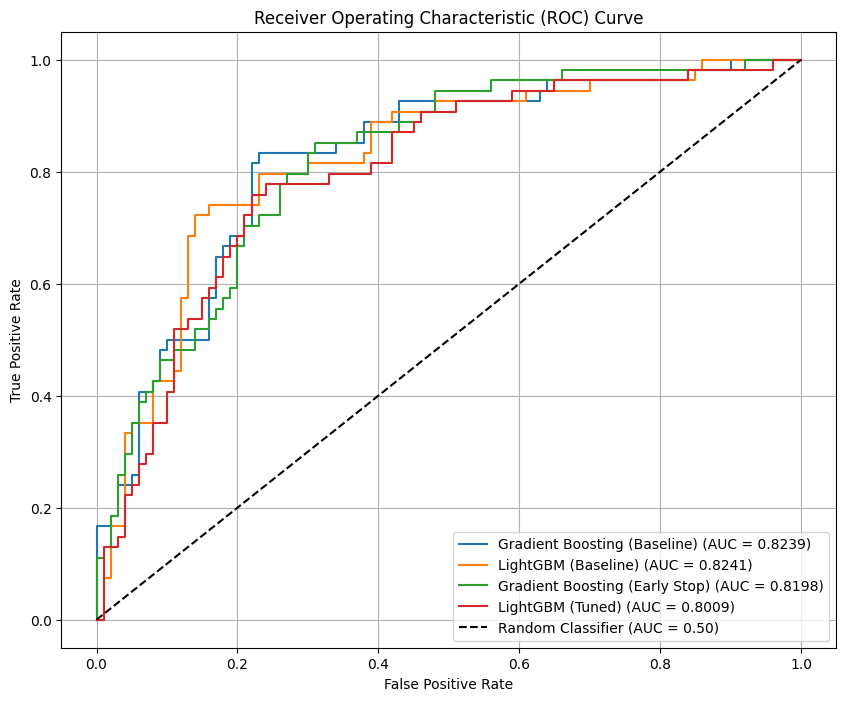

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary of models to evaluate (already trained and available from previous cells)
models_to_evaluate = {
    'Gradient Boosting (Baseline)': gbc_model,
    'LightGBM (Baseline)': lgbm_model,
    'Gradient Boosting (Early Stop)': gbc_es_model,
    'LightGBM (Tuned)': best_lgbm_model
}

plt.figure(figsize=(10, 8))

for name, model in models_to_evaluate.items():
    # Predict probabilities for the positive class
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        # Some models might need specific handling, but for these, predict_proba exists
        continue

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Saving the Best Model and Feature Names

We will save the best performing model, `Gradient Boosting` (baseline), and its feature names so that the model can be reloaded and used for predictions with the correct feature order. We'll explore two common approaches:

In [ ]:
import joblib

# The best performing model was 'Gradient Boosting' (baseline)
best_model = gbc_model

# Get feature names from the training data (X_train_smote is suitable as it reflects the scaled features)
feature_names = X_train_smote.columns.tolist()

print(f"Best model identified: {best_model.__class__.__name__}")
print(f"Feature names: {feature_names}")

Best model identified: GradientBoostingClassifier
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## Approach 1: Bundling Model and Feature Names

This method involves saving the model and its associated feature names as a single Python object (e.g., a dictionary) using `joblib`. This ensures that when the model is loaded, the feature names are automatically available, reducing potential errors from mismatched input features.

In [ ]:
# Create a dictionary to bundle the model and feature names
bundled_model_data = {
    'model': best_model,
    'feature_names': feature_names
}

# Save the bundled object
model_filename_bundled = '/content/drive/MyDrive/diabetes_prediction_model_bundled.joblib'
joblib.dump(bundled_model_data, model_filename_bundled)

print(f"Bundled model and feature names saved to: {model_filename_bundled}")

# --- Test loading the bundled model ---
loaded_bundled_data = joblib.load(model_filename_bundled)
loaded_model_bundled = loaded_bundled_data['model']
loaded_feature_names_bundled = loaded_bundled_data['feature_names']

print(f"\nSuccessfully loaded bundled model: {loaded_model_bundled.__class__.__name__}")
print(f"Loaded feature names (bundled): {loaded_feature_names_bundled}")

Bundled model and feature names saved to: /content/drive/MyDrive/diabetes_prediction_model_bundled.joblib

Successfully loaded bundled model: GradientBoostingClassifier
Loaded feature names (bundled): ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## Approach 2: Saving Model and Feature Names Separately

In this approach, the trained model and the feature names are saved as individual files. This can be useful for modularity or when different parts of the pipeline require only one of these components.

In [ ]:
# Save the model separately
model_filename_separate = '/content/drive/MyDrive/diabetes_prediction_model.joblib'
joblib.dump(best_model, model_filename_separate)

# Save the feature names separately (e.g., as a simple list in a .json or .txt, or using joblib for consistency)
feature_names_filename_separate = '/content/drive/MyDrive/diabetes_prediction_feature_names.joblib'
joblib.dump(feature_names, feature_names_filename_separate)

print(f"Model saved separately to: {model_filename_separate}")
print(f"Feature names saved separately to: {feature_names_filename_separate}")

# --- Test loading the separate components ---
loaded_model_separate = joblib.load(model_filename_separate)
loaded_feature_names_separate = joblib.load(feature_names_filename_separate)

print(f"\nSuccessfully loaded separate model: {loaded_model_separate.__class__.__name__}")
print(f"Loaded feature names (separate): {loaded_feature_names_separate}")

# Verify if they are the same
assert loaded_model_bundled.get_params() == loaded_model_separate.get_params()
assert loaded_feature_names_bundled == loaded_feature_names_separate
print("\nVerification successful: Loaded models and feature names match.")

Model saved separately to: /content/drive/MyDrive/diabetes_prediction_model.joblib
Feature names saved separately to: /content/drive/MyDrive/diabetes_prediction_feature_names.joblib

Successfully loaded separate model: GradientBoostingClassifier
Loaded feature names (separate): ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Verification successful: Loaded models and feature names match.


# Verifying and Loading Saved Models (Optional)

In [ ]:
import joblib
import pandas as pd

# Load the bundled model and feature names
model_filename_bundled = '/content/drive/MyDrive/diabetes_prediction_model_bundled.joblib'
loaded_bundled_data = joblib.load(model_filename_bundled)

loaded_model = loaded_bundled_data['model']
loaded_feature_names = loaded_bundled_data['feature_names']

print(f"Successfully loaded model: {loaded_model.__class__.__name__}")
print(f"Loaded feature names: {loaded_feature_names}")

# Create some sample new data (replace with your actual new data)
# Ensure the new data has the same columns and order as the loaded_feature_names
new_data_raw = pd.DataFrame({
    'Pregnancies': [2, 0, 5],
    'Glucose': [100.0, 150.0, 110.0],
    'BloodPressure': [70.0, 80.0, 65.0],
    'BMI': [25.0, 35.0, 28.0],
    'DiabetesPedigreeFunction': [0.3, 0.6, 0.4],
    'Age': [30, 45, 22]
}, columns=loaded_feature_names)

print("\nSample new data:")
display(new_data_raw.head())

Successfully loaded model: GradientBoostingClassifier
Loaded feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Sample new data:


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,2,100.0,70.0,25.0,0.3,30
1,0,150.0,80.0,35.0,0.6,45
2,5,110.0,65.0,28.0,0.4,22


In [ ]:
# Scale the new data using the already fitted StandardScaler (sc)
# 'sc' object is available from previous cells where feature scaling was performed.
new_data_scaled = sc.transform(new_data_raw)

# Make predictions using the loaded model
prediction_probabilities = loaded_model.predict_proba(new_data_scaled)

print("\nPredictions for new data:")
for i, pred in enumerate(predictions):
    outcome = 'Diabetic' if pred == 1 else 'Non-Diabetic'
    prob_diabetic = prediction_probabilities[i][1] * 100
    print(f"Sample {i+1}: Predicted Outcome = {outcome} (Probability of Diabetic: {prob_diabetic:.2f}%) ")


Predictions for new data:
Sample 1: Predicted Outcome = Non-Diabetic (Probability of Diabetic: 7.61%) 
Sample 2: Predicted Outcome = Diabetic (Probability of Diabetic: 86.35%) 
Sample 3: Predicted Outcome = Non-Diabetic (Probability of Diabetic: 14.51%) 


# **Operationalizing ML Model For Future Predictions or Integration Into Another System**

## Saving the `StandardScaler`

In [ ]:
# Save the StandardScaler to Google Drive
scaler_filename = '/content/drive/MyDrive/diabetes_scaler.joblib'
joblib.dump(sc, scaler_filename)
print(f"StandardScaler saved to: {scaler_filename}")

StandardScaler saved to: /content/drive/MyDrive/diabetes_scaler.joblib


## Saving the Best Model and Feature Names

We will save the best performing model, `Gradient Boosting` (baseline), and its feature names so that the model can be reloaded and used for predictions with the correct feature order. We'll explore two common approaches:

In [ ]:
import joblib

# The best performing model was 'Gradient Boosting' (baseline)
best_model = gbc_model

# Get feature names from the training data (X_train_smote is suitable as it reflects the scaled features)
feature_names = X_train_smote.columns.tolist()

print(f"Best model identified: {best_model.__class__.__name__}")
print(f"Feature names: {feature_names}")

Best model identified: GradientBoostingClassifier
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## Demonstrating End-to-End Prediction with Loaded Model and Scaler

In [ ]:
import joblib
import pandas as pd

# Load the saved model and feature names
model_filename_bundled = '/content/drive/MyDrive/diabetes_prediction_model_bundled.joblib'
loaded_bundled_data = joblib.load(model_filename_bundled)
loaded_model = loaded_bundled_data['model']
loaded_feature_names = loaded_bundled_data['feature_names']

# Load the saved StandardScaler
scaler_filename = '/content/drive/MyDrive/diabetes_scaler.joblib'
loaded_scaler = joblib.load(scaler_filename)

print(f"Model loaded: {loaded_model.__class__.__name__}")
print(f"Scaler loaded: {loaded_scaler.__class__.__name__}")
print(f"Expected feature order: {loaded_feature_names}")

# Define new raw (unscaled) data for prediction
# This data should be in a pandas DataFrame with the same columns as loaded_feature_names
new_raw_data = pd.DataFrame({
    'Pregnancies': [1, 3, 0],
    'Glucose': [100, 140, 95],
    'BloodPressure': [70, 85, 60],
    'BMI': [28.5, 33.0, 22.0],
    'DiabetesPedigreeFunction': [0.25, 0.5, 0.15],
    'Age': [25, 40, 20]
}, columns=loaded_feature_names)

print("\nNew raw data to predict:")
display(new_raw_data)

# 1. Preprocess the new raw data using the loaded scaler
new_data_scaled_for_prediction = loaded_scaler.transform(new_raw_data)

# 2. Make predictions using the loaded model
predictions_final = loaded_model.predict(new_data_scaled_for_prediction)
prediction_probabilities_final = loaded_model.predict_proba(new_data_scaled_for_prediction)

print("\nFinal Predictions for new raw data:")
for i, pred in enumerate(predictions_final):
    outcome = 'Diabetic' if pred == 1 else 'Non-Diabetic'
    prob_diabetic = prediction_probabilities_final[i][1] * 100
    print(f"Sample {i+1} (Age: {new_raw_data.iloc[i]['Age']}, Glucose: {new_raw_data.iloc[i]['Glucose']}): Predicted Outcome = {outcome} (Probability of Diabetic: {prob_diabetic:.2f}%) ")

Model loaded: GradientBoostingClassifier
Scaler loaded: StandardScaler
Expected feature order: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

New raw data to predict:


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,1,100,70,28.5,0.25,25
1,3,140,85,33.0,0.50,40
2,0,95,60,22.0,0.15,20



Final Predictions for new raw data:
Sample 1 (Age: 25.0, Glucose: 100.0): Predicted Outcome = Non-Diabetic (Probability of Diabetic: 16.53%) 
Sample 2 (Age: 40.0, Glucose: 140.0): Predicted Outcome = Diabetic (Probability of Diabetic: 75.62%) 
Sample 3 (Age: 20.0, Glucose: 95.0): Predicted Outcome = Non-Diabetic (Probability of Diabetic: 1.51%) 


In [ ]:
print(model)

LGBMClassifier(learning_rate=0.2, max_depth=10, n_estimators=150,
               random_state=42)
